# Notebook 03b — Multi-target Models for CLD

## 🎯 Goal

Train machine learning models that predict **late-stage clone performance** using **early-stage features only**.

This mirrors a real CLD workflows where:
- late-outcomes are **not available at selection time**
- decisions must rely on **early measurements + model predictions**

---

## Prediction Targets

We train separate models for three key late-stage outcomes:

### 1. Stability
- `qp_drop_pct`
- Relative drop in qP from early window to late window
- Lower is better

### 2. Productivity
- `late_mean_qp`
- Average late-stage qP
- Higher is better

### 3. Quality (temporary)
- `late_mean_aggregation`
- Lower is better

---

## Modeling Strategy

- Use early-stage features (v2)
- Train **independent Random Forest models** for each target
- Evaluate performance on held-out test data

---

## Important Concept

These models do NOT aim to perfectly predict biology.

Instead, they aim to:

> Rank clones correctly for selection decisions

---

## Downstream Usage (Notebook 04b)

Predicted values from this notebook will be used to:

- Score clones using predicted late performance
- Simulate real CLD selection decisions
- Evaluate selection quality (top 10–20%)

---

## Additional Models (Latent Classes)

We also train classifiers for:

- `is_super` → rare high-value clones
- `is_aggressive` → misleading early performers

## Additional Classifier

We also train a binary classifier for:
- 'stable_label_30pct'
    - 1 = stable (qP drop ≤ 30%)
    - 0 = unstable (qP drop > 30%)

## Why this notebook matters

This notebook is the **prediction engine** of the CLD pipeline.

Its outputs will be used in Notebook 04b to:
- filter unstable or low-quality clones
- rank remaining clones by predicted productivity
- simulate real clone selection decisions

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)
import shap

scenario = "legacy"   # "legacy" or "optimized"
n_clones = 5000

DATA_PATH = Path("../data/synthetic/processed") / (
    f"cld_features_with_labels_qp_targets_v2_24_30_{n_clones}_{scenario}.csv"
)

print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

rename_map = {
    "qP_mean": "qP_proxy_mean",
    "qP_p10": "qP_proxy_p10",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

df.head()

Loading: ../data/synthetic/processed/cld_features_with_labels_qp_targets_v2_24_30_5000_legacy.csv


,clone_id,titer_mean,titer_std,titer_min,titer_max,titer_cv,titer_p10,vcd_mean,vcd_std,vcd_min,...,qP_proxy_slope,qP_proxy_slope_3_6,qP_proxy_slope_7_10,qP_proxy_curvature,ddpcr_cn,early_mean_qp,late_mean_qp,late_mean_aggregation,qp_drop_pct,stable_label_30pct
0,CLONE_0001,3.240001,0.244658,2.946003,3.646983,0.075512,3.116997,1.150399e+07,8.543827e+05,1.035721e+07,...,-1.268820e-08,-8.441910e-09,-9.485069e-09,-1.043159e-09,4.0,2.840245e-07,1.685610e-07,6.532632,0.406525,0
1,CLONE_0002,0.890732,0.199584,0.492907,1.080938,0.224068,1.042496,1.436123e+07,8.165488e+05,1.312061e+07,...,-7.610942e-10,5.152232e-11,9.430391e-09,9.378869e-09,2.0,6.264352e-08,2.327035e-08,9.320724,0.628517,0
2,CLONE_0003,5.060018,0.403075,4.469948,5.464666,0.079659,4.596945,7.826375e+06,2.751202e+05,7.427478e+06,...,-2.476998e-08,2.694125e-09,-3.703065e-08,-3.972477e-08,5.0,6.481282e-07,1.766731e-07,4.421152,0.727409,0
3,CLONE_0004,1.223941,0.316260,0.668985,1.593312,0.258395,0.668985,1.562601e+07,1.721244e+06,1.305176e+07,...,-1.083020e-08,-9.071218e-09,-8.397878e-09,6.733401e-10,4.0,8.064730e-08,2.386570e-08,2.158328,0.704064,0
4,CLONE_0005,3.254988,0.137416,3.048111,3.434989,0.042217,3.144411,1.021871e+07,1.226798e+06,8.845936e+06,...,-1.193248e-08,-1.310922e-08,-2.204084e-08,-8.931621e-09,6.0,3.230290e-07,1.898780e-07,2.565377,0.412194,0


In [2]:
# --------------------------------------------------
# Prepare X and targets
# --------------------------------------------------
regression_targets = ["qp_drop_pct", "late_mean_qp", "late_mean_aggregation"]
classification_target = "stable_label_30pct"

# keep row order fixed for alignment
df = df.sort_values("clone_id").reset_index(drop=True)
clone_ids = df["clone_id"].copy()

# defensive removal of legacy / leakage-prone columns
legacy_leak_cols = [
    "productivity_drop_pct",   # old (v1) stability target
    "late_mean_titer",         # old (v1) productivity target
    "late_mean_vcd",           # old (v1) late-stage summary
]

# exclude clone_id + current target columns + legacy leak columns from features
drop_cols = ["clone_id"] + regression_targets + [classification_target] + legacy_leak_cols
X = df.drop(columns=drop_cols, errors="ignore").copy()

# numeric imputation only
X = X.fillna(X.median(numeric_only=True))

# regression targets
y_drop = df["qp_drop_pct"].copy().clip(lower=0.0, upper=1.0)
y_prod = df["late_mean_qp"].copy()
y_agg = df["late_mean_aggregation"].copy().clip(lower=0.0, upper=100.0)

# classification target
y_stable = df[classification_target].copy().astype(int)

print("Dropped from X:", [c for c in drop_cols if c in df.columns])
print("X shape:", X.shape)
print("Regression targets:", y_drop.shape, y_prod.shape, y_agg.shape)
print("Stable classifier target:", y_stable.shape)

Dropped from X: ['clone_id', 'qp_drop_pct', 'late_mean_qp', 'late_mean_aggregation', 'stable_label_30pct']
X shape: (5000, 52)
Regression targets: (5000,) (5000,) (5000,)
Stable classifier target: (5000,)


In [3]:
# --------------------------------------------------
# Train / test split
# --------------------------------------------------
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, shuffle=True
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

id_train = clone_ids.iloc[train_idx].values
id_test = clone_ids.iloc[test_idx].values

# regression
y_drop_train = y_drop.iloc[train_idx].values
y_drop_test = y_drop.iloc[test_idx].values

y_prod_train = y_prod.iloc[train_idx].values
y_prod_test = y_prod.iloc[test_idx].values

y_agg_train = y_agg.iloc[train_idx].values
y_agg_test = y_agg.iloc[test_idx].values

# classification
y_stable_train = y_stable.iloc[train_idx].values
y_stable_test = y_stable.iloc[test_idx].values

print("Train size:", len(train_idx), "Test size:", len(test_idx))
print("Stable prevalence (train/test):", y_stable_train.mean(), y_stable_test.mean())

Train size: 4000 Test size: 1000
Stable prevalence (train/test): 0.25175 0.27


In [4]:
# --------------------------------------------------
# Train 3 Random Forest regressors
# --------------------------------------------------
def fit_rf(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt",
    )
    model.fit(X_train, y_train)
    return model

rf_drop = fit_rf(X_train, y_drop_train)
rf_prod = fit_rf(X_train, y_prod_train)
rf_agg = fit_rf(X_train, y_agg_train)

def eval_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name:22s} MAE={mae:.4f}  R2={r2:.4f}")
    return pred

pred_drop = eval_model("qp_drop (stability)", rf_drop, X_test, y_drop_test)
pred_prod = eval_model("late_qp (productivity)", rf_prod, X_test, y_prod_test)
pred_agg = eval_model("late_agg (quality)", rf_agg, X_test, y_agg_test)

qp_drop (stability)    MAE=0.1375  R2=0.3192
late_qp (productivity) MAE=0.0000  R2=0.1759
late_agg (quality)     MAE=1.8808  R2=0.4849


In [5]:
# --------------------------------------------------
# Stable / unstable classifier
# --------------------------------------------------
def fit_rf_clf(X_train, y_train):
    clf = RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
    )
    clf.fit(X_train, y_train)
    return clf

rf_stable = fit_rf_clf(X_train, y_stable_train)

pred_stable_prob = rf_stable.predict_proba(X_test)[:, 1]
pred_stable_label = (pred_stable_prob >= 0.5).astype(int)

print("=== Stable classifier ===")
print("ROC-AUC:", roc_auc_score(y_stable_test, pred_stable_prob))
print("Average Precision:", average_precision_score(y_stable_test, pred_stable_prob))
print("Predicted stable rate:", pred_stable_label.mean())

=== Stable classifier ===
ROC-AUC: 0.7314205986808726
Average Precision: 0.4822206610585731
Predicted stable rate: 0.139


## Auxiliary classifiers: super clone / aggressive clone

We train two additional classifiers using the same early features:

- `is_super`: rare commercial winner (high P + high S + sustained late performance)
- `is_aggressive`: attractive early false positive (good early productivity, weak stability later)

Why do this?
- The regression models predict late continuous targets
- But the subgroup labels capture biologically meaningful latent regimes
- These classifiers can later be combined into a decision rule:
  - prefer high super probability
  - avoid high aggressive probability

In [6]:
# --------------------------------------------------
# Auxiliary classifiers: super / aggressive
# - Works for both legacy and optimized
# - Automatically skips if a subgroup has only one class in train set
# --------------------------------------------------

LATENT_PATH = Path(f"../data/synthetic/raw/clone_latent_truths_5000_{scenario}.csv")
lat_labels = pd.read_csv(LATENT_PATH)[["clone_id", "is_super", "is_aggressive"]]

# Align labels to the same clone order as df / X
label_df = df[["clone_id"]].merge(lat_labels, on="clone_id", how="left")
label_df[["is_super", "is_aggressive"]] = (
    label_df[["is_super", "is_aggressive"]].fillna(0).astype(int)
)

y_super = label_df["is_super"].copy()
y_aggr = label_df["is_aggressive"].copy()

# Use the SAME split indices as regression
y_super_train = y_super.iloc[train_idx].values
y_super_test  = y_super.iloc[test_idx].values
y_aggr_train  = y_aggr.iloc[train_idx].values
y_aggr_test   = y_aggr.iloc[test_idx].values

print("Super prevalence (train/test):", float(y_super_train.mean()), float(y_super_test.mean()))
print("Aggressive prevalence (train/test):", float(y_aggr_train.mean()), float(y_aggr_test.mean()))

def fit_rf_clf(X_train, y_train):
    clf = RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
    )
    clf.fit(X_train, y_train)
    return clf

def safe_fit_predict_proba(X_train, y_train, X_test, label_name="label"):
    """
    Fit classifier only if training set has both classes.
    Otherwise return zeros so downstream cells still run safely.
    """
    unique_train = np.unique(y_train)

    if len(unique_train) < 2:
        print(f"[SKIP] {label_name}: only one class in training set -> {unique_train.tolist()}")
        return None, np.zeros(len(X_test), dtype=float)

    clf = fit_rf_clf(X_train, y_train)
    proba = clf.predict_proba(X_test)

    # extract positive-class probability safely
    if proba.shape[1] > 1:
        pred_prob = proba[:, 1]
    else:
        pred_prob = np.zeros(len(X_test), dtype=float)

    return clf, pred_prob

def eval_binary_clf(name, y_true, y_prob, k_list=[5, 10, 20, 50]):
    print(f"\n=== {name} ===")
    print("Prevalence:", float(np.mean(y_true)))

    # ROC-AUC / AP only meaningful if both classes exist in test
    if len(np.unique(y_true)) == 2:
        print("ROC-AUC:", float(roc_auc_score(y_true, y_prob)))
        print("Average Precision:", float(average_precision_score(y_true, y_prob)))
    else:
        print("ROC-AUC: n/a (single class in test)")
        print("Average Precision: n/a (single class in test)")

    rows = []
    order = np.argsort(-y_prob)
    for k in k_list:
        top_idx = order[:k]
        capture = float(np.mean(y_true[top_idx]))
        rows.append({"k": k, "capture_rate": capture})

    out = pd.DataFrame(rows)
    display(out)
    return out

# Default outputs so downstream cells never break
rf_super = None
rf_aggr = None
pred_super_prob = np.zeros(len(X_test), dtype=float)
pred_aggr_prob = np.zeros(len(X_test), dtype=float)
super_capture = None
aggr_capture = None

# Super classifier
rf_super, pred_super_prob = safe_fit_predict_proba(
    X_train, y_super_train, X_test, label_name="is_super"
)

# Aggressive classifier
rf_aggr, pred_aggr_prob = safe_fit_predict_proba(
    X_train, y_aggr_train, X_test, label_name="is_aggressive"
)

# Evaluate only if classifier actually trained
if rf_super is not None:
    super_capture = eval_binary_clf("Super classifier", y_super_test, pred_super_prob)
else:
    print("\n[INFO] Super classifier skipped.")

if rf_aggr is not None:
    aggr_capture = eval_binary_clf("Aggressive classifier", y_aggr_test, pred_aggr_prob)
else:
    print("\n[INFO] Aggressive classifier skipped.")

Super prevalence (train/test): 0.01625 0.014
Aggressive prevalence (train/test): 0.03725 0.039

=== Super classifier ===
Prevalence: 0.014
ROC-AUC: 0.9565343378730803
Average Precision: 0.5602560447412546


,k,capture_rate
0,5,0.80
1,10,0.60
2,20,0.45
3,50,0.24



=== Aggressive classifier ===
Prevalence: 0.039
ROC-AUC: 0.9828970890365272
Average Precision: 0.8844872034497064


,k,capture_rate
0,5,1.00
1,10,1.00
2,20,0.90
3,50,0.72


In [7]:
if rf_aggr is not None:
    imp_aggr = pd.Series(rf_aggr.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\n=== Feature importance: aggressive classifier (top 20) ===")
    print(imp_aggr.head(20).to_string())
else:
    print("Aggressive classifier not trained.")


=== Feature importance: aggressive classifier (top 20) ===
titer_std           0.154264
titer_slope         0.141769
titer_cv            0.117519
qP_proxy_cv         0.108419
titer_slope_7_10    0.084993
viability_mean      0.048720
vcd_slope           0.036004
titer_slope_3_6     0.035398
titer_curvature     0.029022
viability_min       0.022190
titer_max           0.020595
vcd_max             0.016584
viability_max       0.016236
titer_mean          0.015328
viability_p10       0.014316
vcd_mean            0.014262
aggregation_std     0.013873
vcd_p10             0.012851
vcd_std             0.010633
vcd_min             0.009557


## SHAP explainability — aggressive false-positive risk model

This section explains why the aggressive classifier assigns high risk to certain clones.

The aggressive classifier predicts whether a clone belongs to the aggressive false-positive subgroup:

> attractive early phenotype, but increased late-stage risk

SHAP helps answer:

- Which early-stage features increase aggressive-risk prediction?
- Which features protect against aggressive-risk prediction?
- Why was a specific high-risk clone flagged?

This is important because a CDMO scientist needs not only a risk score, but also a feature-level explanation.

In [8]:
# --------------------------------------------------
# SHAP explainability — aggressive classifier
# --------------------------------------------------

# SHAP is most useful for the aggressive-risk classifier because
# aggressive false-positive detection is a core differentiator of this project.

if rf_aggr is None:
    print("Aggressive classifier was not trained. Skipping SHAP analysis.")

else:
    # Use a sample for speed and stable notebook rendering
    SHAP_SAMPLE_N = min(300, len(X_test))
    X_shap = X_test.sample(n=SHAP_SAMPLE_N, random_state=42).copy()

    print("Computing SHAP values for aggressive classifier...")
    print("SHAP sample shape:", X_shap.shape)

    explainer_aggr = shap.TreeExplainer(rf_aggr)
    shap_values_raw = explainer_aggr.shap_values(X_shap)

    # Robust handling for different SHAP output formats
    # For binary classifiers:
    # - some versions return list: [class0_values, class1_values]
    # - some versions return array with shape (n, features, classes)
    if isinstance(shap_values_raw, list):
        shap_values_aggr = shap_values_raw[1]
    elif hasattr(shap_values_raw, "ndim") and shap_values_raw.ndim == 3:
        shap_values_aggr = shap_values_raw[:, :, 1]
    else:
        shap_values_aggr = shap_values_raw

    print("SHAP values shape:", np.array(shap_values_aggr).shape)

    # Mean absolute SHAP importance
    shap_importance_aggr = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values_aggr).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    print("\n=== SHAP global importance: aggressive classifier ===")
    display(shap_importance_aggr.head(20))

Computing SHAP values for aggressive classifier...
SHAP sample shape: (300, 52)
SHAP values shape: (300, 52)

=== SHAP global importance: aggressive classifier ===


,feature,mean_abs_shap
30,titer_slope,0.085534
1,titer_std,0.081279
4,titer_cv,0.076759
28,qP_proxy_cv,0.061123
32,titer_slope_7_10,0.042259
12,viability_mean,0.025272
33,titer_curvature,0.017241
31,titer_slope_3_6,0.016242
34,vcd_slope,0.016208
14,viability_min,0.011153


### SHAP summary plot — global aggressive-risk drivers

This plot shows which features push the model toward or away from aggressive-risk prediction.

Interpretation:

- Features near the top are more important.
- Positive SHAP values push prediction toward aggressive-risk.
- Negative SHAP values push prediction away from aggressive-risk.
- Color shows whether the feature value is high or low.

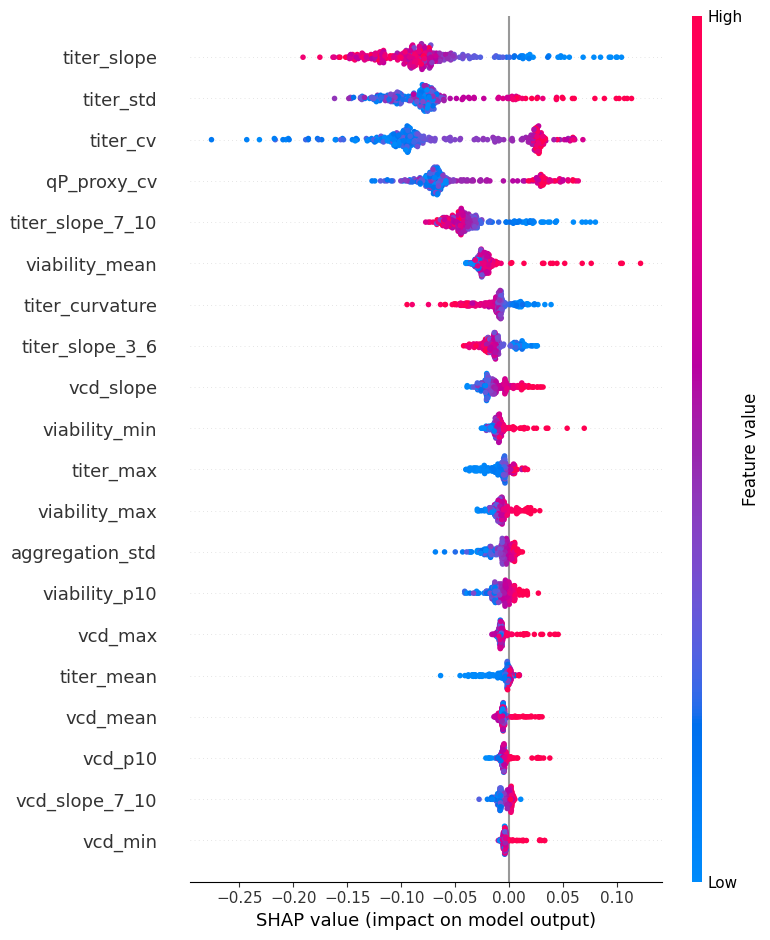

In [9]:
# --------------------------------------------------
# SHAP summary plot — aggressive classifier
# --------------------------------------------------

if rf_aggr is None:
    print("Aggressive classifier was not trained. Skipping SHAP summary plot.")
else:
    shap.summary_plot(
        shap_values_aggr,
        X_shap,
        max_display=20,
        show=True
    )

### Local SHAP explanation — highest aggressive-risk clone

This section explains the single clone with the highest predicted aggressive probability.

This is useful for decision review:

> Why did the model flag this clone as high aggressive-risk?

In [10]:
# --------------------------------------------------
# Local SHAP explanation — highest aggressive-risk clone
# --------------------------------------------------

if rf_aggr is None:
    print("Aggressive classifier was not trained. Skipping local SHAP explanation.")

else:
    # Identify highest-risk clone in the test set
    top_risk_pos = int(np.argmax(pred_aggr_prob))
    top_risk_clone_id = id_test[top_risk_pos]

    x_top = X_test.iloc[[top_risk_pos]].copy()

    shap_values_top_raw = explainer_aggr.shap_values(x_top)

    if isinstance(shap_values_top_raw, list):
        shap_values_top = shap_values_top_raw[1][0]
    elif hasattr(shap_values_top_raw, "ndim") and shap_values_top_raw.ndim == 3:
        shap_values_top = shap_values_top_raw[0, :, 1]
    else:
        shap_values_top = shap_values_top_raw[0]

    local_explain = pd.DataFrame({
        "feature": X_test.columns,
        "feature_value": x_top.iloc[0].values,
        "shap_value": shap_values_top,
        "abs_shap": np.abs(shap_values_top),
    }).sort_values("abs_shap", ascending=False)

    print("=== Highest aggressive-risk clone ===")
    print("clone_id:", top_risk_clone_id)
    print("pred_aggr_prob:", float(pred_aggr_prob[top_risk_pos]))

    if "y_aggr_test" in globals():
        print("true_is_aggressive:", int(y_aggr_test[top_risk_pos]))

    display(local_explain.head(15))

=== Highest aggressive-risk clone ===
clone_id: CLONE_2032
pred_aggr_prob: 0.9681178706028439
true_is_aggressive: 1


,feature,feature_value,shap_value,abs_shap
1,titer_std,2.508043e+00,0.105965,0.105965
30,titer_slope,-1.014424e+00,0.093406,0.093406
32,titer_slope_7_10,-1.071780e+00,0.078330,0.078330
4,titer_cv,2.397510e-01,0.061555,0.061555
28,qP_proxy_cv,4.616696e-01,0.058746,0.058746
33,titer_curvature,-4.294339e-01,0.037251,0.037251
31,titer_slope_3_6,-6.423456e-01,0.029244,0.029244
34,vcd_slope,4.651866e+05,0.028971,0.028971
12,viability_mean,9.189888e+01,-0.020888,0.020888
14,viability_min,8.780945e+01,-0.017547,0.017547


## SHAP Waterfall Plot — Clone-specific Aggressive-Risk Explanation

This plot explains why the model classified the selected clone
as a high aggressive-risk clone.

Positive SHAP values push the prediction toward aggressive-risk,
while negative SHAP values reduce aggressive-risk probability.

This helps interpret whether the model is reacting to:
- unstable productivity trends
- viability collapse signals
- aggregation instability
- other dynamic process features

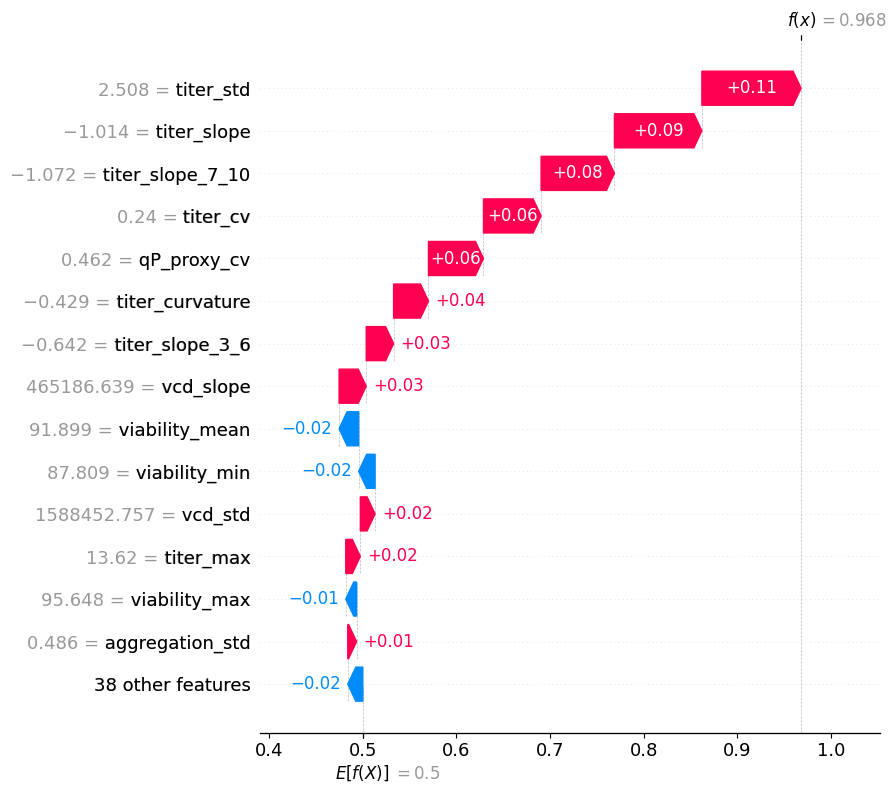

In [11]:
# --------------------------------------------------
# SHAP waterfall plot for top aggressive-risk clone
# --------------------------------------------------

if rf_aggr is None:
    print("Aggressive classifier was not trained. Skipping SHAP waterfall plot.")

else:
    # Use the same top-risk clone selected in the local SHAP explanation cell
    top_risk_pos = int(np.argmax(pred_aggr_prob))
    x_top = X_test.iloc[[top_risk_pos]].copy()

    shap_values_top_raw = explainer_aggr.shap_values(x_top)

    if isinstance(shap_values_top_raw, list):
        shap_values_top = shap_values_top_raw[1][0]
    elif hasattr(shap_values_top_raw, "ndim") and shap_values_top_raw.ndim == 3:
        shap_values_top = shap_values_top_raw[0, :, 1]
    else:
        shap_values_top = shap_values_top_raw[0]

    expected_value = explainer_aggr.expected_value

    if isinstance(expected_value, list):
        expected_value_aggr = expected_value[1]
    elif np.ndim(expected_value) > 0:
        expected_value_aggr = expected_value[1]
    else:
        expected_value_aggr = expected_value

    shap_exp = shap.Explanation(
        values=shap_values_top,
        base_values=expected_value_aggr,
        data=x_top.iloc[0].values,
        feature_names=X_test.columns.tolist(),
    )

    shap.plots.waterfall(shap_exp, max_display=15)

### Evaluate the subgroup classifiers

We use:
- ROC-AUC: ranking quality of probabilities
- Average Precision (AP): more informative under class imbalance
- Top-K capture rate: among the clones with highest predicted subgroup probability,
  how many are truly from that subgroup?

## Rescue scoring for process-optimization candidates

This section adds a first-pass **rescue scoring model**.

A rescue clone is not a direct final selection.  
Instead, it is a clone that has enough upside to justify additional process optimization.

In this notebook, rescue potential is estimated using predicted late-stage outcomes:

- high predicted late qP
- borderline qP drop risk
- borderline aggregation risk
- low-to-moderate aggressive probability
- not already an obvious stable pass clone

The resulting columns are saved into the prediction table for Notebook 04b:

- `pred_rescue_score`
- `pred_rescue_label`

Notebook 04b will later use these values inside the decision engine.

In [12]:
# --------------------------------------------------
# Save prediction table for Notebook 04b
# --------------------------------------------------
OUT_PRED = Path("../data/synthetic/processed") / (
    f"predictions_03b_qp_{n_clones}_{scenario}.csv"
)

pred_table = pd.DataFrame({
    "clone_id": id_test,
    "pred_qp_drop": pred_drop,
    "pred_late_qp": pred_prod,
    "pred_late_agg": pred_agg,
    "pred_stable_prob": pred_stable_prob,
    "pred_stable_label": pred_stable_label,
    "true_qp_drop": y_drop_test,
    "true_late_qp": y_prod_test,
    "true_late_agg": y_agg_test,
    "true_stable_label": y_stable_test,
})

# Optional subgroup classifier outputs
pred_table["pred_super_prob"] = pred_super_prob if "pred_super_prob" in globals() else 0.0
pred_table["pred_aggr_prob"] = pred_aggr_prob if "pred_aggr_prob" in globals() else 0.0

# --------------------------------------------------
# Add true aggressive labels for offline FP evaluation
# --------------------------------------------------
# true_is_aggressive is synthetic-truth only.
# It is used for evaluation, not for real deployment scoring.

if "y_aggr_test" in globals():
    pred_table["true_is_aggressive"] = y_aggr_test.astype(int)
else:
    # Fallback: if the variable is not available, merge from latent truth file.
    # This should rarely be needed if the auxiliary classifier cell was run.
    LATENT_PATH = Path(f"../data/synthetic/raw/clone_latent_truths_5000_{scenario}.csv")
    lat_aggr = pd.read_csv(LATENT_PATH)[["clone_id", "is_aggressive"]]

    pred_table = pred_table.merge(
        lat_aggr.rename(columns={"is_aggressive": "true_is_aggressive"}),
        on="clone_id",
        how="left",
    )

    pred_table["true_is_aggressive"] = (
        pred_table["true_is_aggressive"]
        .fillna(0)
        .astype(int)
    )

print("Aggressive truth prevalence in prediction table:")
print(pred_table["true_is_aggressive"].mean())

# --------------------------------------------------
# Rescue scoring model — auto-tuned
# --------------------------------------------------
def z01(s):
    s = pd.Series(s).astype(float)
    denom = s.max() - s.min()
    if denom < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (denom + 1e-12)

def triangular_band_score(x, low, high, peak=None):
    x = pd.Series(x).astype(float)
    if peak is None:
        peak = (low + high) / 2

    score = pd.Series(np.zeros(len(x)), index=x.index)

    left = (x >= low) & (x <= peak)
    right = (x > peak) & (x <= high)

    score.loc[left] = (x.loc[left] - low) / (peak - low + 1e-12)
    score.loc[right] = (high - x.loc[right]) / (high - peak + 1e-12)

    return score.clip(0, 1)

# Base rescue components
pred_table["rescue_upside_qp"] = z01(pred_table["pred_late_qp"])

pred_table["rescue_stability_band"] = triangular_band_score(
    pred_table["pred_qp_drop"],
    low=0.20,
    high=0.65,
    peak=0.35,
)

pred_table["rescue_quality_band"] = triangular_band_score(
    pred_table["pred_late_agg"],
    low=5.0,
    high=14.0,
    peak=8.5,
)

pred_table["rescue_aggressive_penalty"] = 1.0 - z01(pred_table["pred_aggr_prob"])
pred_table["rescue_not_already_pass"] = 1.0 - z01(pred_table["pred_stable_prob"])

# --------------------------------------------------
# Auto-tune rescue score weights
# --------------------------------------------------
candidate_weights = [
    dict(w_qp=0.20, w_stab=0.35, w_qual=0.30, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.25, w_stab=0.30, w_qual=0.30, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.25, w_stab=0.35, w_qual=0.25, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.30, w_stab=0.30, w_qual=0.25, w_aggr=0.10, w_notpass=0.05),
    dict(w_qp=0.25, w_stab=0.30, w_qual=0.25, w_aggr=0.15, w_notpass=0.05),
    dict(w_qp=0.20, w_stab=0.30, w_qual=0.35, w_aggr=0.10, w_notpass=0.05),
]

RESCUE_FRAC = 0.10

def compute_rescue_score(df, w):
    raw = (
        w["w_qp"] * df["rescue_upside_qp"]
        + w["w_stab"] * df["rescue_stability_band"]
        + w["w_qual"] * df["rescue_quality_band"]
        + w["w_aggr"] * df["rescue_aggressive_penalty"]
        + w["w_notpass"] * df["rescue_not_already_pass"]
    )
    return z01(raw)

def evaluate_rescue_weights(df, w, rescue_frac=0.10):
    tmp = df.copy()
    tmp["score"] = compute_rescue_score(tmp, w)
    thr = tmp["score"].quantile(1 - rescue_frac)
    tmp["label"] = (tmp["score"] >= thr).astype(int)

    rescue = tmp[tmp["label"] == 1]
    non_rescue = tmp[tmp["label"] == 0]

    rescue_qp_ratio = rescue["pred_late_qp"].mean() / (
        non_rescue["pred_late_qp"].mean() + 1e-12
    )
    rescue_stable_rate = rescue["true_stable_label"].mean()
    rescue_agg = rescue["pred_late_agg"].mean()

    stable_target = 0.20
    agg_target = 8.0

    objective = (
        1.00 * np.log1p(rescue_qp_ratio)
        - 1.50 * abs(rescue_stable_rate - stable_target)
        - 0.08 * abs(rescue_agg - agg_target)
    )

    return {
        **w,
        "objective": float(objective),
        "rescue_qp_ratio": float(rescue_qp_ratio),
        "rescue_stable_rate": float(rescue_stable_rate),
        "rescue_pred_late_agg_mean": float(rescue_agg),
        "rescue_threshold": float(thr),
    }

rescue_tuning = pd.DataFrame([
    evaluate_rescue_weights(pred_table, w, rescue_frac=RESCUE_FRAC)
    for w in candidate_weights
]).sort_values("objective", ascending=False)

display(rescue_tuning)

best_w = rescue_tuning.iloc[0].to_dict()

print("=== Best rescue weights ===")
print(best_w)

pred_table["pred_rescue_score"] = compute_rescue_score(pred_table, best_w)

rescue_thr = pred_table["pred_rescue_score"].quantile(1 - RESCUE_FRAC)
pred_table["pred_rescue_label"] = (
    pred_table["pred_rescue_score"] >= rescue_thr
).astype(int)

print("\n=== Rescue scoring summary ===")
print("Rescue threshold:", rescue_thr)
print("Predicted rescue rate:", pred_table["pred_rescue_label"].mean())

print("\n=== Rescue sanity checks ===")
print("Stable rate by rescue label:")
print(pred_table.groupby("pred_rescue_label")["true_stable_label"].mean())

print("\nPredicted late qP by rescue label:")
print(pred_table.groupby("pred_rescue_label")["pred_late_qp"].mean())

print("\nPredicted late aggregation by rescue label:")
print(pred_table.groupby("pred_rescue_label")["pred_late_agg"].mean())

display(
    pred_table.sort_values("pred_rescue_score", ascending=False)[[
        "clone_id",
        "pred_rescue_score",
        "pred_rescue_label",
        "pred_late_qp",
        "pred_qp_drop",
        "pred_late_agg",
        "pred_stable_prob",
        "pred_aggr_prob",
        "true_late_qp",
        "true_qp_drop",
        "true_late_agg",
        "true_stable_label",
    ]].head(15)
)

# --------------------------------------------------
# Save prediction table and create evaluation dataframe
# --------------------------------------------------
pred_table.to_csv(OUT_PRED, index=False)
print("Saved:", OUT_PRED)

# Working evaluation table used by downstream evaluation cells
df_eval = pred_table.copy()

display(df_eval.head())

print("\nColumns in pred_table:")
print(df_eval.columns.tolist())

Aggressive truth prevalence in prediction table:
0.039


,w_qp,w_stab,w_qual,w_aggr,w_notpass,objective,rescue_qp_ratio,rescue_stable_rate,rescue_pred_late_agg_mean,rescue_threshold
3,0.30,0.30,0.25,0.10,0.05,1.078196,3.045465,0.37,8.805008,0.584498
1,0.25,0.30,0.30,0.10,0.05,0.853451,2.126897,0.35,8.769883,0.630369
5,0.20,0.30,0.35,0.10,0.05,0.756533,1.804293,0.34,8.807733,0.679663
4,0.25,0.30,0.25,0.15,0.05,0.718547,1.812743,0.37,8.757669,0.636195
0,0.20,0.35,0.30,0.10,0.05,0.672181,1.684805,0.37,8.755338,0.676623
2,0.25,0.35,0.25,0.10,0.05,0.668959,1.711101,0.38,8.729952,0.630913


=== Best rescue weights ===
{'w_qp': 0.3, 'w_stab': 0.3, 'w_qual': 0.25, 'w_aggr': 0.1, 'w_notpass': 0.05, 'objective': 1.078195913803791, 'rescue_qp_ratio': 3.04546511793632, 'rescue_stable_rate': 0.37, 'rescue_pred_late_agg_mean': 8.80500769986349, 'rescue_threshold': 0.5844979169741313}

=== Rescue scoring summary ===
Rescue threshold: 0.5844979169741313
Predicted rescue rate: 0.1

=== Rescue sanity checks ===
Stable rate by rescue label:
pred_rescue_label
0    0.258889
1    0.370000
Name: true_stable_label, dtype: float64

Predicted late qP by rescue label:
pred_rescue_label
0    1.399405e-07
1    4.261869e-07
Name: pred_late_qp, dtype: float64

Predicted late aggregation by rescue label:
pred_rescue_label
0    5.880144
1    8.805008
Name: pred_late_agg, dtype: float64


,clone_id,pred_rescue_score,pred_rescue_label,pred_late_qp,pred_qp_drop,pred_late_agg,pred_stable_prob,pred_aggr_prob,true_late_qp,true_qp_drop,true_late_agg,true_stable_label
180,CLONE_4625,1.000000,1,5.537450e-06,0.357910,8.834887,0.486118,0.028849,1.017815e-05,0.440572,11.935039,0
621,CLONE_3254,0.815263,1,4.310815e-06,0.310529,8.071338,0.621432,0.008511,8.830813e-06,0.000000,9.991042,1
730,CLONE_4878,0.776958,1,4.417263e-06,0.452348,10.140637,0.199006,0.022511,4.980082e-06,0.663904,5.051639,0
898,CLONE_3393,0.680823,1,6.301821e-07,0.376229,8.988781,0.314863,0.001442,5.362019e-07,0.531948,8.743881,0
246,CLONE_2179,0.678745,1,1.730618e-07,0.357722,8.718476,0.426794,0.000000,1.532782e-07,0.382953,10.875310,0
511,CLONE_2520,0.676299,1,1.574354e-07,0.346800,8.358086,0.460809,0.000000,1.808132e-07,0.261930,7.855895,1
803,CLONE_1437,0.670519,1,3.335818e-07,0.361212,8.198667,0.418763,0.013238,3.337555e-07,0.377841,8.859319,0
438,CLONE_0178,0.669283,1,1.360451e-07,0.358188,8.758432,0.478198,0.003025,1.633495e-07,0.199100,10.843779,1
385,CLONE_1551,0.668916,1,7.373963e-08,0.359088,8.545940,0.563495,0.000000,5.896650e-08,0.490425,11.037808,0
860,CLONE_3289,0.668404,1,9.450229e-08,0.353524,8.276280,0.465213,0.001549,8.844222e-08,0.395850,12.357106,0


Saved: ../data/synthetic/processed/predictions_03b_qp_5000_legacy.csv


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,pred_super_prob,pred_aggr_prob,true_is_aggressive,rescue_upside_qp,rescue_stability_band,rescue_quality_band,rescue_aggressive_penalty,rescue_not_already_pass,pred_rescue_score,pred_rescue_label
0,CLONE_1502,0.381373,2.711177e-08,9.583127,0.370940,0,0.111023,4.176362e-08,12.566994,1,0.000000,0.024314,0,0.000518,0.895422,0.803068,0.974885,0.486344,0.598822,1
1,CLONE_2587,0.489493,6.445184e-08,3.127400,0.169707,0,0.691891,3.691256e-08,0.918511,0,0.000000,0.001179,0,0.007290,0.535023,0.000000,0.998782,0.769478,0.264869,0
2,CLONE_2654,0.362087,3.071979e-08,7.313653,0.492969,0,0.009193,4.002863e-08,6.558486,1,0.004355,0.014202,0,0.001172,0.959708,0.661044,0.985331,0.314649,0.571715,0
3,CLONE_1056,0.353752,6.793292e-08,6.868662,0.478848,0,0.708930,3.026369e-08,7.990409,0,0.004891,0.001310,0,0.007922,0.987492,0.533903,0.998647,0.334518,0.549744,0
4,CLONE_0706,0.616517,1.729449e-07,8.278383,0.036653,0,0.740570,1.029717e-07,7.441547,0,0.012486,0.072412,0,0.026969,0.111609,0.936681,0.925203,0.956685,0.397218,0



Columns in pred_table:
['clone_id', 'pred_qp_drop', 'pred_late_qp', 'pred_late_agg', 'pred_stable_prob', 'pred_stable_label', 'true_qp_drop', 'true_late_qp', 'true_late_agg', 'true_stable_label', 'pred_super_prob', 'pred_aggr_prob', 'true_is_aggressive', 'rescue_upside_qp', 'rescue_stability_band', 'rescue_quality_band', 'rescue_aggressive_penalty', 'rescue_not_already_pass', 'pred_rescue_score', 'pred_rescue_label']


## False-positive warning evaluation — aggressive clone recall

This section evaluates whether the model can warn against **aggressive false-positive clones**.

In this project, an aggressive clone means:

> a clone that may look attractive early, but is likely to underperform or collapse later.

This is one of the most important business-relevant metrics because a CDMO wants to avoid advancing clones that look promising early but fail during late-stage evaluation.

We evaluate:

- aggressive clone prevalence
- warning threshold based on predicted aggressive probability
- recall: among true aggressive clones, how many were warned?
- precision: among warned clones, how many were truly aggressive?
- Top-K aggressive capture by predicted aggressive probability

This is an offline synthetic-data evaluation only.

In [13]:
# --------------------------------------------------
# False-positive warning evaluation — aggressive clone recall
# --------------------------------------------------

required_fp_cols = ["true_is_aggressive", "pred_aggr_prob"]
missing_fp_cols = [c for c in required_fp_cols if c not in df_eval.columns]

if missing_fp_cols:
    raise ValueError(
        f"Missing columns for FP recall evaluation: {missing_fp_cols}. "
        "Make sure true_is_aggressive and pred_aggr_prob are saved in pred_table."
    )

fp_eval = df_eval.copy()
fp_eval["true_is_aggressive"] = fp_eval["true_is_aggressive"].astype(int)

# Use a top-risk percentile threshold instead of 0.5.
# Aggressive clones are rare, so calibrated probabilities may be low.
AGGR_WARNING_FRAC = 0.05
aggr_warning_threshold = fp_eval["pred_aggr_prob"].quantile(1 - AGGR_WARNING_FRAC)

fp_eval["aggressive_warning"] = (
    fp_eval["pred_aggr_prob"] >= aggr_warning_threshold
).astype(int)

n_true_aggr = int(fp_eval["true_is_aggressive"].sum())
n_warned = int(fp_eval["aggressive_warning"].sum())
n_true_warned = int(
    ((fp_eval["true_is_aggressive"] == 1) & (fp_eval["aggressive_warning"] == 1)).sum()
)

aggressive_recall = n_true_warned / max(1, n_true_aggr)
aggressive_precision = n_true_warned / max(1, n_warned)

fp_summary = pd.DataFrame([{
    "n_total": len(fp_eval),
    "true_aggressive_n": n_true_aggr,
    "true_aggressive_rate": n_true_aggr / max(1, len(fp_eval)),
    "warning_threshold": aggr_warning_threshold,
    "warning_n": n_warned,
    "warning_rate": n_warned / max(1, len(fp_eval)),
    "aggressive_warning_recall": aggressive_recall,
    "aggressive_warning_precision": aggressive_precision,
}])

display(fp_summary)

# Top-K capture: among the highest predicted aggressive-risk clones,
# how many are truly aggressive?
K_LIST_FP = [5, 10, 20, 50, 100]

fp_topk_rows = []
ranked_aggr = fp_eval.sort_values("pred_aggr_prob", ascending=False).copy()

for k in K_LIST_FP:
    top = ranked_aggr.head(k)
    fp_topk_rows.append({
        "k": k,
        "true_aggressive_in_topk": int(top["true_is_aggressive"].sum()),
        "aggressive_capture_rate_in_topk": float(top["true_is_aggressive"].mean()),
        "fraction_of_all_aggressive_captured": float(
            top["true_is_aggressive"].sum() / max(1, n_true_aggr)
        ),
    })

fp_topk_table = pd.DataFrame(fp_topk_rows)
display(fp_topk_table)

print("=== Interpretation ===")
print(f"Aggressive warning recall: {aggressive_recall:.3f}")
print(f"Aggressive warning precision: {aggressive_precision:.3f}")
print(
    "Higher recall means the model is better at warning about early attractive "
    "but late-risk aggressive clones."
)

,n_total,true_aggressive_n,true_aggressive_rate,warning_threshold,warning_n,warning_rate,aggressive_warning_recall,aggressive_warning_precision
0,1000,39,0.039,0.265927,50,0.05,0.923077,0.72


,k,true_aggressive_in_topk,aggressive_capture_rate_in_topk,fraction_of_all_aggressive_captured
0,5,5,1.00,0.128205
1,10,10,1.00,0.256410
2,20,18,0.90,0.461538
3,50,36,0.72,0.923077
4,100,38,0.38,0.974359


=== Interpretation ===
Aggressive warning recall: 0.923
Aggressive warning precision: 0.720
Higher recall means the model is better at warning about early attractive but late-risk aggressive clones.


## Utility-based ranking evaluation

This section evaluates whether the model is useful for **clone selection**, not only for raw regression accuracy.

We check:

- **Spearman correlation** for ranking consistency
- **Top-k overlap** between predicted and true utility
- **Top-k true-good rate** among selected clones

This is closer to the real CLD objective:
selecting the best clones early, not just minimizing RMSE.

In [14]:
# --------------------------------------------------
# Spearman + Top-K evaluation
# --------------------------------------------------

def z(s):
    s = pd.Series(s).astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def spearman(a, b):
    return spearmanr(a, b).correlation

def topk_overlap(true_scores, pred_scores, k):
    true_top = set(pd.Series(true_scores).nlargest(k).index)
    pred_top = set(pd.Series(pred_scores).nlargest(k).index)
    return len(true_top & pred_top) / k

def topk_recall_of_true_good(pred_rank, true_good_mask, k):
    top_idx = pred_rank.nlargest(k).index
    return true_good_mask.loc[top_idx].mean()

required_eval_cols = [
    "true_qp_drop", "pred_qp_drop",
    "true_late_qp", "pred_late_qp",
    "true_late_agg", "pred_late_agg"
]
missing_eval = [c for c in required_eval_cols if c not in df_eval.columns]
if missing_eval:
    raise ValueError(f"df_eval is missing required columns: {missing_eval}")

print("=== Spearman (ranking correlation) ===")
print("qp_drop (lower better):", spearman(-df_eval["true_qp_drop"], -df_eval["pred_qp_drop"]))
print("late_qp (higher better):", spearman(df_eval["true_late_qp"], df_eval["pred_late_qp"]))
print("late_agg (lower better):", spearman(-df_eval["true_late_agg"], -df_eval["pred_late_agg"]))

# biosimilar utility
df_eval["true_util_bio"] = (
    1.0 * z(df_eval["true_late_qp"])
    - 1.0 * z(df_eval["true_qp_drop"])
    - 0.2 * z(df_eval["true_late_agg"])
)
df_eval["pred_util_bio"] = (
    1.0 * z(df_eval["pred_late_qp"])
    - 1.0 * z(df_eval["pred_qp_drop"])
    - 0.2 * z(df_eval["pred_late_agg"])
)

# novel / ADC utility
df_eval["true_util_novel"] = (
    1.0 * z(df_eval["true_late_qp"])
    - 1.0 * z(df_eval["true_qp_drop"])
    - 1.0 * z(df_eval["true_late_agg"])
)
df_eval["pred_util_novel"] = (
    1.0 * z(df_eval["pred_late_qp"])
    - 1.0 * z(df_eval["pred_qp_drop"])
    - 1.0 * z(df_eval["pred_late_agg"])
)

K_LIST = [5, 10, 20, 50]

print("\n=== Top-K evaluation using biosimilar utility ===")
for k in K_LIST:
    overlap = topk_overlap(df_eval["true_util_bio"], df_eval["pred_util_bio"], k)
    print(f"Top-{k} overlap (true vs pred utility): {overlap:.3f}")

GOOD_FRAC = 0.10
good_threshold = df_eval["true_util_bio"].quantile(1 - GOOD_FRAC)
df_eval["true_good_bio"] = df_eval["true_util_bio"] >= good_threshold

print("\n=== Top-K true-good rate among predicted picks (biosimilar) ===")
pred_rank = df_eval["pred_util_bio"]
for k in K_LIST:
    rate = topk_recall_of_true_good(pred_rank, df_eval["true_good_bio"], k)
    print(f"Predicted top-{k}: fraction that are truly top {int(GOOD_FRAC*100)}% good = {rate:.3f}")

=== Spearman (ranking correlation) ===
qp_drop (lower better): 0.5028812947139952
late_qp (higher better): 0.9256546696546698
late_agg (lower better): 0.6856599976599977

=== Top-K evaluation using biosimilar utility ===
Top-5 overlap (true vs pred utility): 0.800
Top-10 overlap (true vs pred utility): 0.500
Top-20 overlap (true vs pred utility): 0.250
Top-50 overlap (true vs pred utility): 0.160

=== Top-K true-good rate among predicted picks (biosimilar) ===
Predicted top-5: fraction that are truly top 10% good = 0.800
Predicted top-10: fraction that are truly top 10% good = 0.700
Predicted top-20: fraction that are truly top 10% good = 0.450
Predicted top-50: fraction that are truly top 10% good = 0.280


In [15]:
# --------------------------------------------------
# Feature importance
# --------------------------------------------------
imp_drop = pd.Series(rf_drop.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_prod = pd.Series(rf_prod.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_agg = pd.Series(rf_agg.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_stable = pd.Series(rf_stable.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n=== Top features: qp_drop ===")
print(imp_drop.head(15).to_string())

print("\n=== Top features: late_qp ===")
print(imp_prod.head(15).to_string())

print("\n=== Top features: late_agg ===")
print(imp_agg.head(15).to_string())

print("\n=== Top features: stable classifier ===")
print(imp_stable.head(15).to_string())

if rf_aggr is not None:
    imp_aggr = pd.Series(rf_aggr.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\n=== Top features: aggressive classifier ===")
    print(imp_aggr.head(15).to_string())
else:
    print("\nAggressive classifier not trained.")


=== Top features: qp_drop ===
titer_slope         0.151758
titer_std           0.101104
titer_slope_7_10    0.057152
titer_slope_3_6     0.046236
qP_proxy_cv         0.041976
titer_cv            0.040723
vcd_slope           0.031016
titer_max           0.024765
titer_mean          0.023146
titer_p10           0.021740
viability_mean      0.020495
titer_curvature     0.019522
titer_min           0.018438
viability_slope     0.016386
viability_min       0.016384

=== Top features: late_qp ===
titer_p10        0.141874
titer_min        0.127811
titer_mean       0.073234
qP_proxy_p10     0.072480
qP_proxy_min     0.067215
qP_proxy_mean    0.044072
qP_proxy_max     0.041605
vcd_p10          0.041164
vcd_mean         0.039331
titer_max        0.039324
early_mean_qp    0.038105
viability_p10    0.036820
viability_max    0.035037
vcd_min          0.031918
vcd_max          0.029342

=== Top features: late_agg ===
aggregation_mean          0.151633
aggregation_min           0.151045
aggregation

## A) Define two utility modes (business objectives)

We evaluate two different "success definitions" depending on business goals.

### 1) Biosimilar / commercial volume mode
- Prioritize **high productivity** (late qP ↑)
- Prioritize **stability** (qP drop ↓)
- Quality (aggregation) matters, but with a **lower weight**

### 2) Novel / ADC / high-quality mode
- Prioritize **quality** (aggregation ↓) more strongly
- Still require productivity and stability, but quality has a higher weight

We compute utility from:

- **true late outcomes** ("offline evaluation")
- **predicted late outcomes** ("model-based ranking")

In [16]:
# --------------------------------------------------
# Utility-based ranking evaluation
# --------------------------------------------------

def z(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

# ---- Required columns in df_eval (test-set prediction table) ----
required = [
    "true_qp_drop",
    "pred_qp_drop",
    "true_late_qp",
    "pred_late_qp",
    "true_late_agg",
    "pred_late_agg",
]
missing = [c for c in required if c not in df_eval.columns]
if missing:
    raise ValueError(
        f"df_eval is missing required columns: {missing}. "
        "Make sure 03b created df_eval with qP-based true/pred targets."
    )

# ---- Utility weights ----
# Biosimilar: productivity + stability dominate
W_BIO = dict(qp=1.0, drop=1.0, agg=0.2)

# Novel/ADC: quality gets larger weight
W_NOVEL = dict(qp=1.0, drop=1.0, agg=1.0)

def compute_utility(df: pd.DataFrame, weights: dict, prefix: str) -> pd.Series:
    return (
        weights["qp"] * z(df[f"{prefix}_late_qp"])
        - weights["drop"] * z(df[f"{prefix}_qp_drop"])
        - weights["agg"] * z(df[f"{prefix}_late_agg"])
    )

# Create z-score utilities (true vs predicted) for both modes
df_eval["true_util_bio"] = compute_utility(df_eval, W_BIO, "true")
df_eval["pred_util_bio"] = compute_utility(df_eval, W_BIO, "pred")

df_eval["true_util_novel"] = compute_utility(df_eval, W_NOVEL, "true")
df_eval["pred_util_novel"] = compute_utility(df_eval, W_NOVEL, "pred")

display(df_eval[[
    "true_util_bio", "pred_util_bio",
    "true_util_novel", "pred_util_novel"
]].head())

,true_util_bio,pred_util_bio,true_util_novel,pred_util_novel
0,1.032173,-0.084743,-0.492968,-1.270080
1,-1.015188,-0.469116,0.279491,0.589272
2,1.877311,0.304273,1.806686,-0.092296
3,-1.526406,0.506410,-1.943665,0.264501
4,-1.615101,-1.881235,-1.899494,-2.613101


## B) Redefine "bottom-right" using utility (top-X% elite)

The traditional CLD "bottom-right" idea uses two thresholds:

- **late qP / productivity** in the top quantile
- **qP drop** in the bottom quantile

However, our CLD decision is now **multi-objective**:

- productivity
- stability
- quality

So instead of using a simple two-threshold rule, we redefine "bottom-right" as:

> **Elite set = top X% by true utility**

We compute elite sets for:

- Biosimilar utility mode
- Novel / ADC utility mode

This makes evaluation consistent with how clones will later be ranked in the decision engine.

In [17]:
# Elite definitions by utility
GOOD_FRAC_LIST = [0.10, 0.05, 0.02, 0.01]   # top 10%, 5%, 2%, 1%

def mark_elite(df: pd.DataFrame, util_col: str, frac: float, out_col: str):
    thr = df[util_col].quantile(1 - frac)
    df[out_col] = (df[util_col] >= thr).astype(int)
    return thr

elite_thresholds = []

for frac in GOOD_FRAC_LIST:
    pct = int(frac * 100)

    thr_bio = mark_elite(df_eval, "true_util_bio", frac, f"elite_bio_{pct}")
    thr_nov = mark_elite(df_eval, "true_util_novel", frac, f"elite_novel_{pct}")

    elite_thresholds.append({
        "frac": frac,
        "thr_true_util_bio": float(thr_bio),
        "thr_true_util_novel": float(thr_nov),
        "n_elite_bio": int(df_eval[f"elite_bio_{pct}"].sum()),
        "n_elite_novel": int(df_eval[f"elite_novel_{pct}"].sum()),
    })

elite_thresholds_df = pd.DataFrame(elite_thresholds)
elite_thresholds_df

,frac,thr_true_util_bio,thr_true_util_novel,n_elite_bio,n_elite_novel
0,0.10,1.363041,1.737267,100,100
1,0.05,1.798303,2.295341,50,50
2,0.02,2.078262,2.978119,20,20
3,0.01,2.210390,3.329501,10,10


## C) Dominance + Top-K capture comparison (biosimilar vs novel)

We compare how well predicted utilities recover elite clones under two modes:

### Metrics
1) **Spearman**: ranking correlation between true utility and predicted utility
2) **Top-K overlap**: how many of the predicted top-K are also in true top-K (strict)
3) **Top-K elite rate**: among predicted top-K, what fraction are in the true elite set (practical)
4) **Subgroup capture** (if available): super/aggressive fractions among predicted top-K

This mirrors real CLD decision making:
- You keep only a small Top-K set for late-stage validation.

In [18]:
from scipy.stats import spearmanr

K_LIST = [5, 10, 20, 50]

def topk_overlap(true_score: pd.Series, pred_score: pd.Series, k: int) -> float:
    true_top = set(true_score.sort_values(ascending=False).head(k).index)
    pred_top = set(pred_score.sort_values(ascending=False).head(k).index)
    return len(true_top & pred_top) / k

def elite_rate_in_topk(df: pd.DataFrame, pred_util_col: str, elite_col: str, k: int) -> float:
    top = df.sort_values(pred_util_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def subgroup_rates_in_topk(df: pd.DataFrame, pred_util_col: str, k: int):
    top = df.sort_values(pred_util_col, ascending=False).head(k)
    out = {}
    if "true_is_super" in top.columns:
        out["super_rate"] = float(top["true_is_super"].mean())
    if "ture_is_aggressive" in top.columns:
        out["aggressive_rate"] = float(top["true_is_aggressive"].mean())
    return out

def eval_mode(mode_name: str, true_util: str, pred_util: str, elite_col: str):
    print(f"\n==================== {mode_name} ====================")
    # Spearman (ranking)
    rho = spearmanr(df_eval[true_util], df_eval[pred_util]).correlation
    print("Spearman(true_util vs pred_util):", rho)

    rows = []
    for k in K_LIST:
        rows.append({
            "mode": mode_name,
            "k": k,
            "topk_overlap": topk_overlap(df_eval[true_util], df_eval[pred_util], k),
            "elite_rate_in_topk": elite_rate_in_topk(df_eval, pred_util, elite_col, k),
            **subgroup_rates_in_topk(df_eval, pred_util, k),
        })

    out = pd.DataFrame(rows)
    display(out)
    return out

# Evaluate both modes at elite top-10% (you can change to elite_bio_5 / elite_bio_1, etc.)
res_bio = eval_mode(
    "Biosimilar mode (elite = top10%)",
    true_util = "true_util_bio",
    pred_util = "pred_util_bio",
    elite_col = "elite_bio_10",
)

res_novel = eval_mode(
    "Novel/ADC mode (elite = top10%)",
    true_util = "true_util_novel",
    pred_util = "pred_util_novel",
    elite_col = "elite_novel_10",
)

res_bio_2 = eval_mode(
    "Biosimilar mode (elite = top2%)",
    true_util ='true_util_bio',
    pred_util = "pred_util_bio",
    elite_col = "elite_bio_2" 
)

res_novel_2 = eval_mode(
    "Novel/ADC mode (elite = top2%)",
    true_util = "true_util_novel",
    pred_util = "pred_util_novel",
    elite_col = "elite_novel_2"
)


# Combine results for side-by-side viewing
results_compare = pd.concat([res_bio, res_novel, res_bio_2, res_novel_2], 
                            ignore_index=True)
results_compare


==================== Biosimilar mode (elite = top10%) ====================
Spearman(true_util vs pred_util): 0.48817238017238024


,mode,k,topk_overlap,elite_rate_in_topk
0,Biosimilar mode (elite = top10%),5,0.80,0.80
1,Biosimilar mode (elite = top10%),10,0.50,0.70
2,Biosimilar mode (elite = top10%),20,0.25,0.45
3,Biosimilar mode (elite = top10%),50,0.16,0.28



==================== Novel/ADC mode (elite = top10%) ====================
Spearman(true_util vs pred_util): 0.6069191949191949


,mode,k,topk_overlap,elite_rate_in_topk
0,Novel/ADC mode (elite = top10%),5,0.80,1.00
1,Novel/ADC mode (elite = top10%),10,0.40,0.60
2,Novel/ADC mode (elite = top10%),20,0.30,0.45
3,Novel/ADC mode (elite = top10%),50,0.28,0.40



==================== Biosimilar mode (elite = top2%) ====================
Spearman(true_util vs pred_util): 0.48817238017238024


,mode,k,topk_overlap,elite_rate_in_topk
0,Biosimilar mode (elite = top2%),5,0.80,0.80
1,Biosimilar mode (elite = top2%),10,0.50,0.50
2,Biosimilar mode (elite = top2%),20,0.25,0.25
3,Biosimilar mode (elite = top2%),50,0.16,0.14



==================== Novel/ADC mode (elite = top2%) ====================
Spearman(true_util vs pred_util): 0.6069191949191949


,mode,k,topk_overlap,elite_rate_in_topk
0,Novel/ADC mode (elite = top2%),5,0.80,0.80
1,Novel/ADC mode (elite = top2%),10,0.40,0.40
2,Novel/ADC mode (elite = top2%),20,0.30,0.30
3,Novel/ADC mode (elite = top2%),50,0.28,0.16


,mode,k,topk_overlap,elite_rate_in_topk
0,Biosimilar mode (elite = top10%),5,0.80,0.80
1,Biosimilar mode (elite = top10%),10,0.50,0.70
2,Biosimilar mode (elite = top10%),20,0.25,0.45
3,Biosimilar mode (elite = top10%),50,0.16,0.28
4,Novel/ADC mode (elite = top10%),5,0.80,1.00
5,Novel/ADC mode (elite = top10%),10,0.40,0.60
6,Novel/ADC mode (elite = top10%),20,0.30,0.45
7,Novel/ADC mode (elite = top10%),50,0.28,0.40
8,Biosimilar mode (elite = top2%),5,0.80,0.80
9,Biosimilar mode (elite = top2%),10,0.50,0.50


## D) Precision@K and NDCG@K (Top-10% and Top-5% elites)

### Why these metrics?
- We care about **ranking** (Top-K decisions), not perfect numeric prediction.
- R²/MAE can look poor even when Top-K ranking is useful.

### Definitions
**Elite label**:
- elite = top X% by **true utility** (offline evaluation)

**Precision@K**:
- Among the predicted Top-K clones (ranked by predicted utility),
  what fraction are truly elite?

**NDCG@K** (Normalized Discounted Cumulative Gain):
- A ranking-quality score that rewards placing elite clones higher in the list.
- It is more sensitive to the top of the ranking than Spearman.

We compute these for:
- Biosimilar mode utility (pred_util_bio vs elite_bio_*)
- Novel/ADC mode utility (pred_util_novel vs elite_novel_*)
- Elite thresholds: top 10% and top 5%
- K = [5, 10, 20, 50]

In [19]:
K_LIST = [5, 10, 20, 50]

def precision_at_k(df: pd.DataFrame, score_col: str, elite_col: str, k: int) -> float:
    top = df.sort_values(score_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def ndcg_at_k(df: pd.DataFrame, score_col: str, elite_col: str, k: int) -> float:
    """
    NDCG@K with binary relevance (elite=1 else 0).
    """
    top = df.sort_values(score_col, ascending=False).head(k)
    rel = top[elite_col].values.astype(float)

    # DCG: sum(rel_i / log2(i+2))
    discounts = 1.0 / np.log2(np.arange(2, len(rel) + 2))
    dcg = float(np.sum(rel * discounts))

    # IDCG: ideal DCG (sorted rel descending)
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts)) + 1e-12

    return dcg / idcg

def eval_prec_ndcg(df: pd.DataFrame, mode_name: str, score_col: str, elite_col: str):
    rows = []
    for k in K_LIST:
        rows.append({
            "mode": mode_name,
            "elite_def": elite_col,
            "k": k,
            "precision@k": precision_at_k(df, score_col, elite_col, k),
            "ndcg@k": ndcg_at_k(df, score_col, elite_col, k),
        })
    return pd.DataFrame(rows)

# We assume you already created these columns in earlier cells:
# - pred_util_bio, pred_util_novel
# - elite_bio_10, elite_bio_5
# - elite_novel_10, elite_novel_5
needed = ["pred_util_bio","pred_util_novel","elite_bio_10","elite_bio_5","elite_bio_2","elite_novel_10","elite_novel_5", "elite_novel_2"]
missing = [c for c in needed if c not in df_eval.columns]
if missing:
    raise ValueError(f"Missing columns in df_eval: {missing}. "
                     "Make sure you ran the Utility+Elite definition cells first.")

res = []
res.append(eval_prec_ndcg(df_eval, "biosimilar", "pred_util_bio", "elite_bio_10"))
res.append(eval_prec_ndcg(df_eval, "biosimilar", "pred_util_bio", "elite_bio_5"))
res.append(eval_prec_ndcg(df_eval, "biosimilar", "pred_util_bio", "elite_bio_2"))

res.append(eval_prec_ndcg(df_eval, "novel/ADC", "pred_util_novel", "elite_novel_10"))
res.append(eval_prec_ndcg(df_eval, "novel/ADC", "pred_util_novel", "elite_novel_5"))
res.append(eval_prec_ndcg(df_eval, "novel/ADC", "pred_util_novel", "elite_novel_2"))

prec_ndcg_table = pd.concat(res, ignore_index=True)
prec_ndcg_table

,mode,elite_def,k,precision@k,ndcg@k
0,biosimilar,elite_bio_10,5,0.80,1.000000
1,biosimilar,elite_bio_10,10,0.70,0.973120
2,biosimilar,elite_bio_10,20,0.45,0.957837
3,biosimilar,elite_bio_10,50,0.28,0.899545
4,biosimilar,elite_bio_5,5,0.80,1.000000
5,biosimilar,elite_bio_5,10,0.60,0.963487
6,biosimilar,elite_bio_5,20,0.30,0.963487
7,biosimilar,elite_bio_5,50,0.16,0.903250
8,biosimilar,elite_bio_2,5,0.80,1.000000
9,biosimilar,elite_bio_2,10,0.50,0.981848


In [20]:
# Optional: pivot for easier reading
pivot = prec_ndcg_table.pivot_table(
    index=["mode","elite_def","k"],
    values=["precision@k","ndcg@k"]
).reset_index()
pivot

,mode,elite_def,k,ndcg@k,precision@k
0,biosimilar,elite_bio_10,5,1.000000,0.80
1,biosimilar,elite_bio_10,10,0.973120,0.70
2,biosimilar,elite_bio_10,20,0.957837,0.45
3,biosimilar,elite_bio_10,50,0.899545,0.28
4,biosimilar,elite_bio_2,5,1.000000,0.80
5,biosimilar,elite_bio_2,10,0.981848,0.50
6,biosimilar,elite_bio_2,20,0.981848,0.25
7,biosimilar,elite_bio_2,50,0.902118,0.14
8,biosimilar,elite_bio_5,5,1.000000,0.80
9,biosimilar,elite_bio_5,10,0.963487,0.60


## E) Utility Weight Sweep (Grid Search) — Find the best weights for Top-K selection

### Why do this?

Our final CLD decision is multi-objective:

- late productivity (**late qP**): higher is better
- stability loss (**qP drop**): lower is better
- quality risk (**aggregation**): lower is better

But we do NOT know the best trade-off weights in advance.

So we sweep candidate weights and evaluate which combinations produce the best **Top-K clone ranking**.

### What we optimize

We compare predicted ranking quality against true ranking quality using:

- **Precision@K**  
  How many true-elite clones appear in predicted Top-K

- **NDCG@K**  
  Ranking quality, with higher reward for correct ordering near the top

We sweep weights for two business modes:

1. **Biosimilar / commercial mode**  
   prioritize late qP + stability, with lower aggregation weight

2. **Novel / ADC mode**  
   prioritize quality more strongly, with higher aggregation weight

This is an **offline evaluation** step using true late outcomes.

In real CLD deployment, we would apply the selected weights to **predicted late outcomes only**.

In [21]:
# --------------------------------------------------
# E) Utility Weight Sweep (Grid Search)
# --------------------------------------------------

K_LIST = [5, 10, 20, 50]
ELITE_FRACS = [0.10, 0.05, 0.02]   # top 10%, 5%, 2%

def z(s):
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def precision_at_k(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def ndcg_at_k(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    rel = top[elite_col].values.astype(float)
    discounts = 1.0 / np.log2(np.arange(2, len(rel) + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts)) + 1e-12
    return dcg / idcg

def make_utility(df, prefix, w_qp, w_drop, w_agg):
    # utility = + qP - drop - agg (all z-scored)
    return (
        w_qp * z(df[f"{prefix}_late_qp"])
        - w_drop * z(df[f"{prefix}_qp_drop"])
        - w_agg * z(df[f"{prefix}_late_agg"])
    )

def mark_elite(df, util_col, frac):
    thr = df[util_col].quantile(1 - frac)
    return (df[util_col] >= thr).astype(int)

# --- Required columns check ---
required = [
    "true_qp_drop", "pred_qp_drop",
    "true_late_qp", "pred_late_qp",
    "true_late_agg", "pred_late_agg"
]
missing = [c for c in required if c not in df_eval.columns]
if missing:
    raise ValueError(
        f"Missing columns in df_eval: {missing}. "
        "Make sure your prediction table contains qP-based true_* and pred_* columns."
    )

# --- Build a working copy ---
work = df_eval.copy()

# --- Weight grids ---
# Biosimilar: agg weight small
grid_bio = {
    "w_qp": [0.5, 1.0, 1.5, 2.0],
    "w_drop": [0.5, 1.0, 1.5, 2.0],
    "w_agg": [0.0, 0.1, 0.2, 0.3],
}

# Novel/ADC: agg weight larger
grid_novel = {
    "w_qp": [0.5, 1.0, 1.5],
    "w_drop": [0.5, 1.0, 1.5],
    "w_agg": [0.5, 1.0, 1.5, 2.0],
}

def run_sweep(mode_name, grid):
    rows = []

    for w_qp in grid["w_qp"]:
        for w_drop in grid["w_drop"]:
            for w_agg in grid["w_agg"]:
                tmp = work.copy()

                # define utilities
                tmp["true_util"] = make_utility(tmp, "true", w_qp, w_drop, w_agg)
                tmp["pred_util"] = make_utility(tmp, "pred", w_qp, w_drop, w_agg)

                # evaluate for each elite frac and each K
                for frac in ELITE_FRACS:
                    elite_col = f"elite_{int(frac*100)}"
                    tmp[elite_col] = mark_elite(tmp, "true_util", frac)

                    for k in K_LIST:
                        rows.append({
                            "mode": mode_name,
                            "w_qp": w_qp,
                            "w_drop": w_drop,
                            "w_agg": w_agg,
                            "elite_frac": frac,
                            "k": k,
                            "precision@k": precision_at_k(tmp, "pred_util", elite_col, k),
                            "ndcg@k": ndcg_at_k(tmp, "pred_util", elite_col, k),
                        })

    return pd.DataFrame(rows)

bio_sweep = run_sweep("biosimilar", grid_bio)
novel_sweep = run_sweep("novel/ADC", grid_novel)
sweep = pd.concat([bio_sweep, novel_sweep], ignore_index=True)

# --- Choose a primary objective for selection ---
TARGET_FRAC = 0.10
TARGET_K = 20

subset = sweep[
    (sweep["elite_frac"] == TARGET_FRAC) &
    (sweep["k"] == TARGET_K)
].copy()

subset = subset.sort_values(["precision@k", "ndcg@k"], ascending=False)

print("Top candidates by Precision@20 (elite top10%), tie-break NDCG@20:")
display(subset.head(15))

Top candidates by Precision@20 (elite top10%), tie-break NDCG@20:


,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
578,biosimilar,2.0,0.5,0.0,0.1,20,0.65,0.977796
398,biosimilar,1.5,0.5,0.1,0.1,20,0.60,0.985596
410,biosimilar,1.5,0.5,0.2,0.1,20,0.60,0.985596
386,biosimilar,1.5,0.5,0.0,0.1,20,0.60,0.984106
590,biosimilar,2.0,0.5,0.1,0.1,20,0.60,0.982792
602,biosimilar,2.0,0.5,0.2,0.1,20,0.60,0.982792
614,biosimilar,2.0,0.5,0.3,0.1,20,0.60,0.982792
1070,novel/ADC,1.5,0.5,1.0,0.1,20,0.60,0.969054
230,biosimilar,1.0,0.5,0.3,0.1,20,0.60,0.953235
1082,novel/ADC,1.5,0.5,1.5,0.1,20,0.60,0.949492


In [22]:
TARGET_FRAC = 0.02
TARGET_K = 20

subset_top2 = sweep[(sweep["elite_frac"] == TARGET_FRAC) & (sweep["k"] == TARGET_K)].copy()
subset_top2 = subset_top2.sort_values(["precision@k", "ndcg@k"], ascending=False)

print("Top candidates by Precision@20 (elite top2%), tie-break NDCG@20:")
subset_top2.head(15)

Top candidates by Precision@20 (elite top2%), tie-break NDCG@20:


,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
586,biosimilar,2.0,0.5,0.0,0.02,20,0.55,0.987133
598,biosimilar,2.0,0.5,0.1,0.02,20,0.50,0.981482
610,biosimilar,2.0,0.5,0.2,0.02,20,0.45,0.988006
622,biosimilar,2.0,0.5,0.3,0.02,20,0.45,0.986748
394,biosimilar,1.5,0.5,0.0,0.02,20,0.45,0.971392
202,biosimilar,1.0,0.5,0.0,0.02,20,0.40,0.984041
634,biosimilar,2.0,1.0,0.0,0.02,20,0.40,0.984041
646,biosimilar,2.0,1.0,0.1,0.02,20,0.40,0.984041
214,biosimilar,1.0,0.5,0.1,0.02,20,0.40,0.982121
658,biosimilar,2.0,1.0,0.2,0.02,20,0.40,0.982121


In [23]:
subset[subset["mode"] == "biosimilar"].head(10)

,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
578,biosimilar,2.0,0.5,0.0,0.1,20,0.65,0.977796
398,biosimilar,1.5,0.5,0.1,0.1,20,0.60,0.985596
410,biosimilar,1.5,0.5,0.2,0.1,20,0.60,0.985596
386,biosimilar,1.5,0.5,0.0,0.1,20,0.60,0.984106
590,biosimilar,2.0,0.5,0.1,0.1,20,0.60,0.982792
602,biosimilar,2.0,0.5,0.2,0.1,20,0.60,0.982792
614,biosimilar,2.0,0.5,0.3,0.1,20,0.60,0.982792
230,biosimilar,1.0,0.5,0.3,0.1,20,0.60,0.953235
422,biosimilar,1.5,0.5,0.3,0.1,20,0.55,0.978404
74,biosimilar,0.5,1.0,0.2,0.1,20,0.55,0.936187


In [24]:
subset[subset["mode"] == "novel/ADC"].head(10)

,mode,w_qp,w_drop,w_agg,elite_frac,k,precision@k,ndcg@k
1070,novel/ADC,1.5,0.5,1.0,0.1,20,0.60,0.969054
1082,novel/ADC,1.5,0.5,1.5,0.1,20,0.60,0.949492
854,novel/ADC,0.5,1.0,2.0,0.1,20,0.60,0.854590
794,novel/ADC,0.5,0.5,1.5,0.1,20,0.60,0.839618
842,novel/ADC,0.5,1.0,1.5,0.1,20,0.60,0.809152
1106,novel/ADC,1.5,1.0,0.5,0.1,20,0.55,0.959903
926,novel/ADC,1.0,0.5,1.0,0.1,20,0.55,0.938823
902,novel/ADC,0.5,1.5,2.0,0.1,20,0.55,0.855435
782,novel/ADC,0.5,0.5,1.0,0.1,20,0.55,0.772556
998,novel/ADC,1.0,1.0,2.0,0.1,20,0.55,0.772556


## F) Heatmap of utility weight sweep

To better understand how utility weights affect ranking quality, we visualize the sweep result as a heatmap.

### What this heatmap shows
- x-axis: `w_titer`
- y-axis: `w_drop`
- cell value: `precision@k` or `ndcg@k`
- `w_agg` is fixed for each heatmap panel

This lets us see:
- which combinations of productivity/stability weighting work best
- whether biosimilar and novel/ADC modes prefer different utility regions
- how sensitive the model is to the chosen objective function

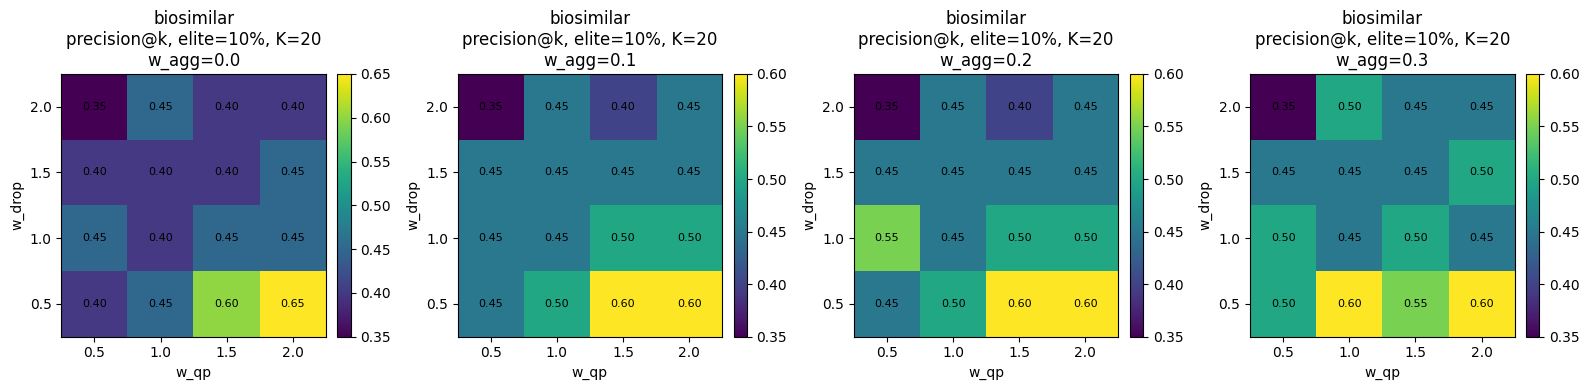

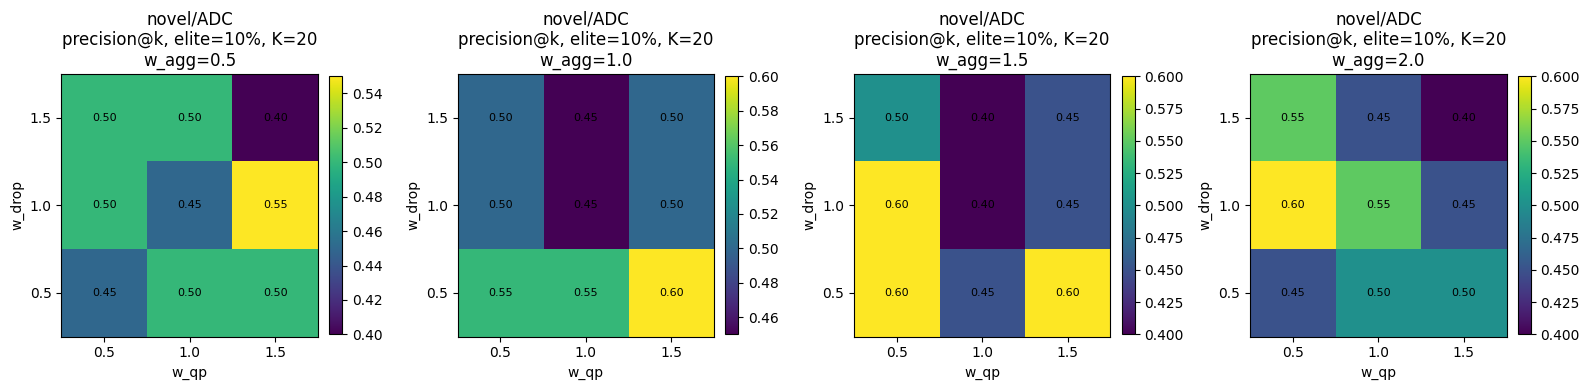

In [25]:

# Choose what to inspect
TARGET_K = 20
TARGET_ELITE = 0.10   # top 10%
METRIC = "precision@k"   # or "ndcg@k"

def plot_weight_heatmaps(sweep_df, mode_name, metric="precision@k", elite_frac=0.10, k=20):
    sub = sweep_df[
        (sweep_df["mode"] == mode_name) &
        (sweep_df["elite_frac"] == elite_frac) &
        (sweep_df["k"] == k)
    ].copy()

    w_agg_values = sorted(sub["w_agg"].unique())

    n_panels = len(w_agg_values)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), squeeze=False)
    axes = axes[0]

    for ax, wagg in zip(axes, w_agg_values):
        tmp = sub[sub["w_agg"] == wagg].copy()

        pivot = tmp.pivot_table(
            index="w_drop",
            columns="w_qp",
            values=metric
        ).sort_index(ascending=False)

        im = ax.imshow(pivot.values, aspect="auto")
        ax.set_title(f"{mode_name}\n{metric}, elite={int(elite_frac*100)}%, K={k}\nw_agg={wagg}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("w_qp")
        ax.set_ylabel("w_drop")

        # annotate cells
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

plot_weight_heatmaps(sweep, "biosimilar", metric=METRIC, elite_frac=TARGET_ELITE, k=TARGET_K)
plot_weight_heatmaps(sweep, "novel/ADC", metric=METRIC, elite_frac=TARGET_ELITE, k=TARGET_K)

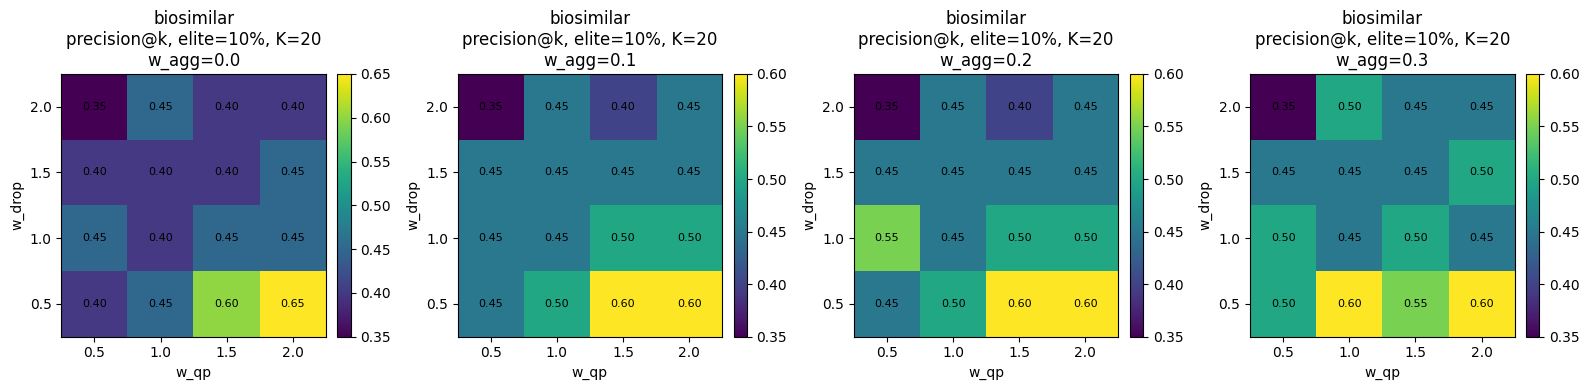

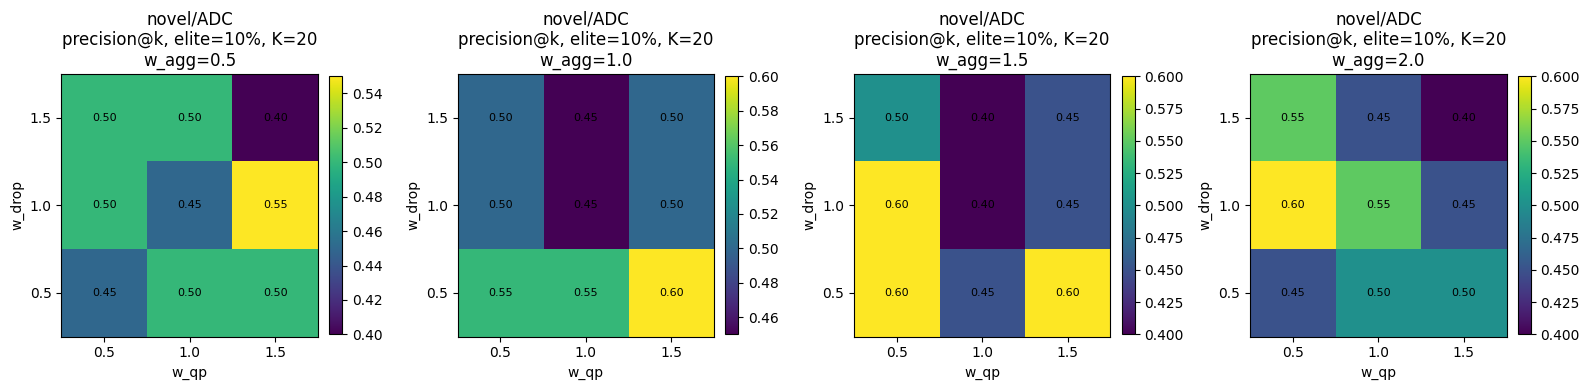

In [26]:
plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="precision@k", elite_frac=0.10, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="precision@k", elite_frac=0.10, k=20)

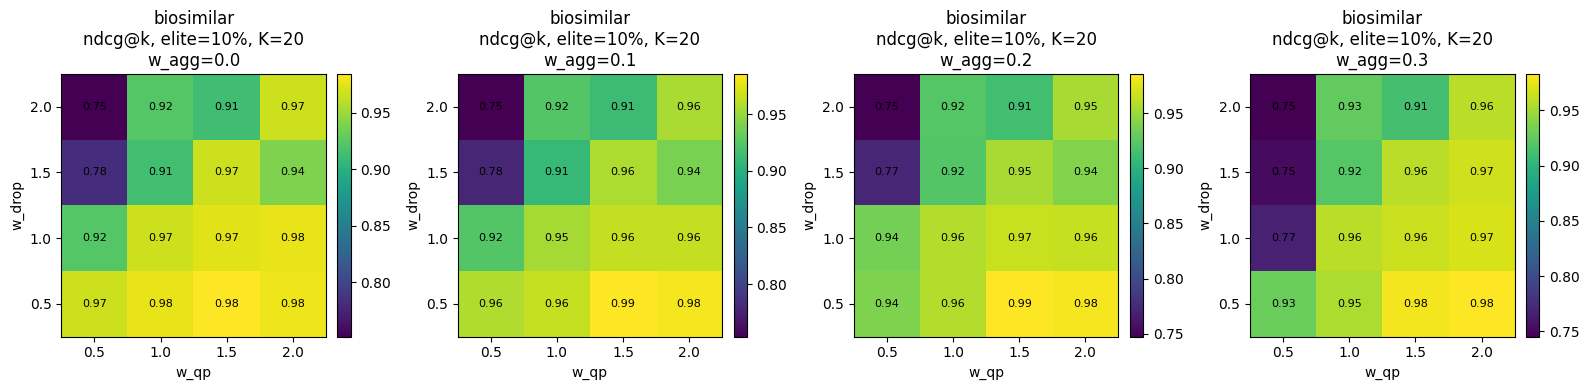

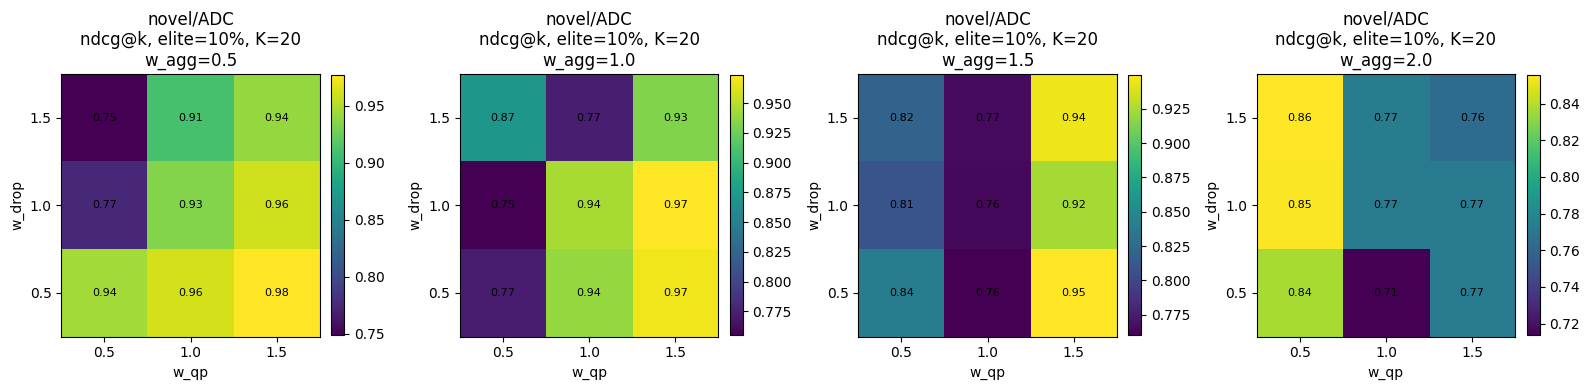

In [27]:
plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="ndcg@k", elite_frac=0.10, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="ndcg@k", elite_frac=0.10, k=20)

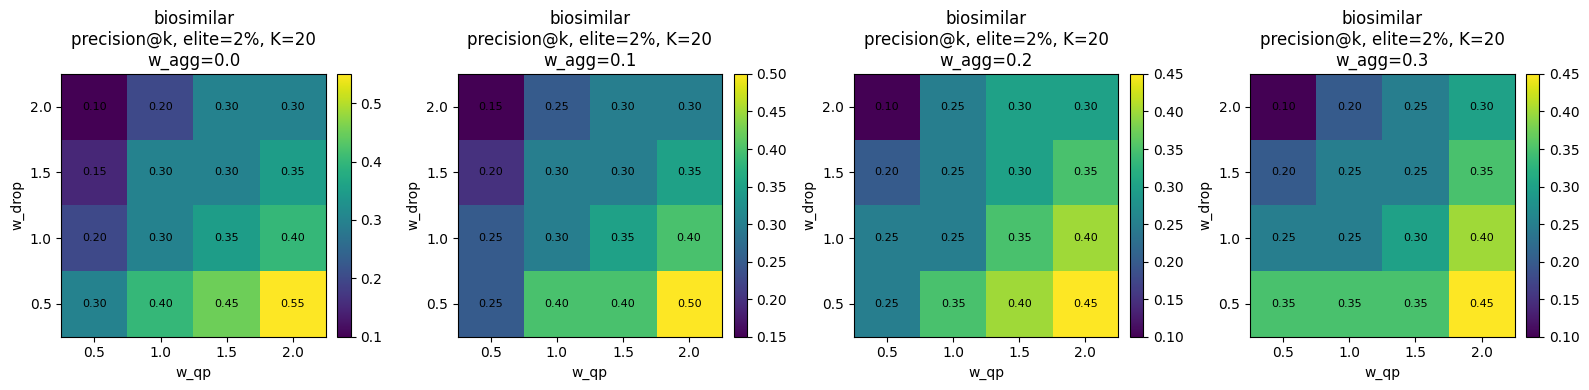

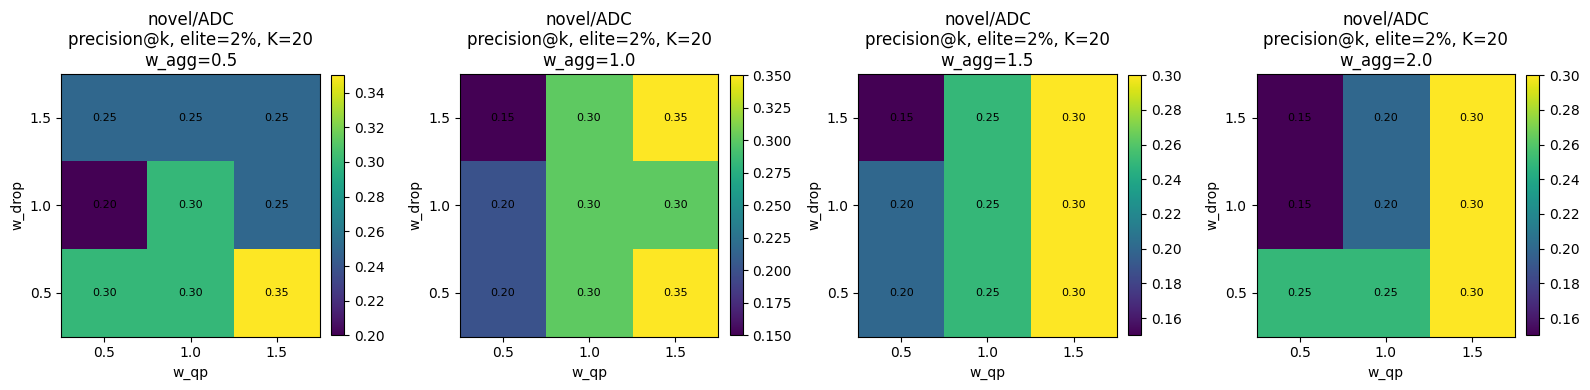

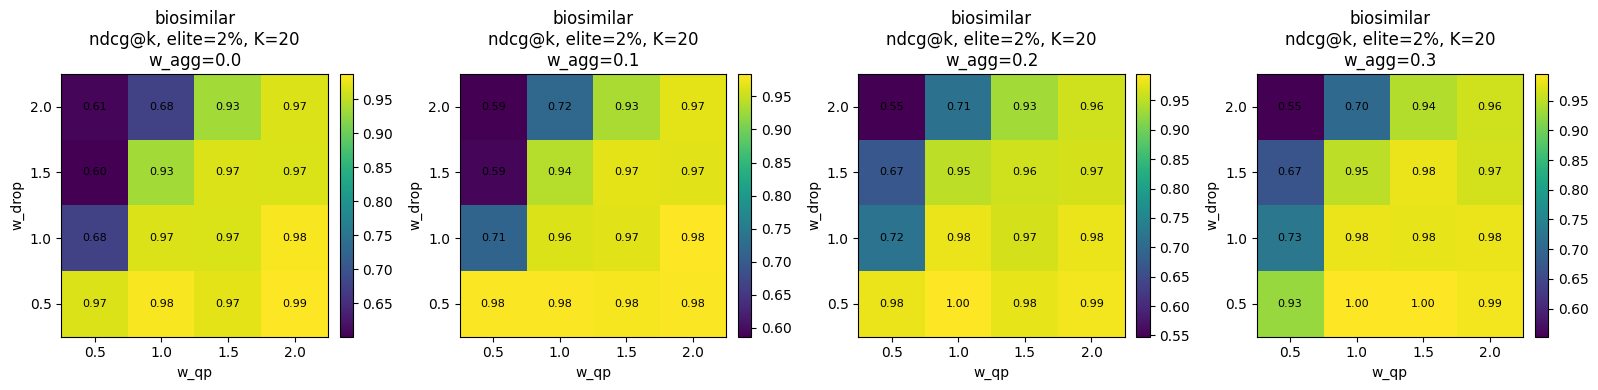

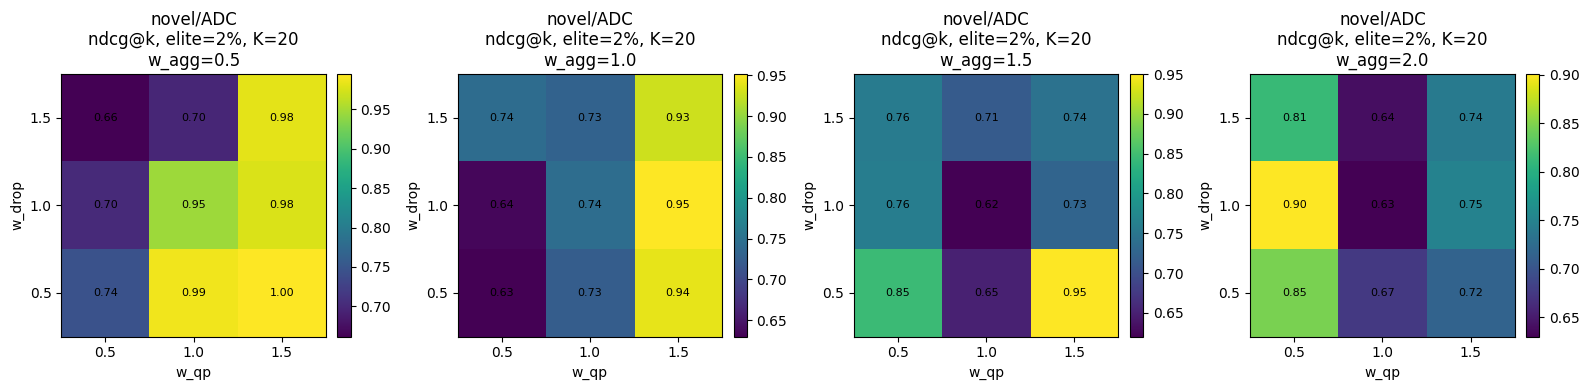

In [28]:
plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="precision@k", elite_frac=0.02, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="precision@k", elite_frac=0.02, k=20)

plot_weight_heatmaps(sweep, mode_name="biosimilar", metric="ndcg@k", elite_frac=0.02, k=20)
plot_weight_heatmaps(sweep, mode_name="novel/ADC", metric="ndcg@k", elite_frac=0.02, k=20)

## Sanity Check 1 — Feature leakage check

We verify that the feature matrix `X` does **not** contain:

- late-stage target columns
- derived prediction columns
- utility columns
- elite labels
- subgroup target labels

This is the most important sanity check when performance looks unusually high.

Expected result:
- no exact forbidden columns in `X`
- no suspicious late-stage label leakage

In [29]:
print("X shape:", X.shape)
print("Columns in X that look suspicious:")
sus = [c for c in X.columns if (
    "late_" in c.lower()
    or "drop" in c.lower()
    or "stable" in c.lower()
    or "utility" in c.lower()
    or "elite" in c.lower()
    or c.lower().startswith("true_")
    or c.lower().startswith("pred_")
)]
print(sus)

X shape: (5000, 52)
Columns in X that look suspicious:
[]


In [30]:
# --------------------------------------------------
# Sanity Check 1 — Feature leakage check
# --------------------------------------------------

# Exact forbidden columns: targets, predictions, utilities, subgroup labels
forbidden_exact = {
    # current qP-based targets
    "late_mean_qp",
    "qp_drop_pct",
    "stable_label_30pct",
    "late_mean_aggregation",

    # old naming (keep here too, in case old files were mixed in)
    "productivity_drop_pct",
    "late_mean_titer",

    # prediction-table columns
    "true_qp_drop",
    "pred_qp_drop",
    "true_late_qp",
    "pred_late_qp",
    "true_late_agg",
    "pred_late_agg",
    "true_stable_label",
    "pred_stable_prob",
    "pred_stable_label",

    # old prediction-table naming
    "true_drop",
    "pred_drop",
    "true_late_titer",
    "pred_late_titer",

    # utility / ranking derived columns
    "true_util_bio",
    "pred_util_bio",
    "true_util_novel",
    "pred_util_novel",
    "true_util",
    "pred_util",

    # elite flags
    "elite",
    "elite_10",
    "elite_5",
    "elite_2",

    # subgroup labels
    "is_super",
    "is_aggressive",
}

# Pattern-based suspicious columns
forbidden_patterns = [
    "late_mean_",
    "true_",
    "pred_",
    "utility",
    "util_",
    "elite",
]

exact_hits = [c for c in X.columns if c in forbidden_exact]
pattern_hits = [c for c in X.columns if any(p in c.lower() for p in forbidden_patterns)]

print("=== Leakage Check ===")
print("Exact forbidden hits:", exact_hits)
print("Pattern-based suspicious hits:", pattern_hits)

if exact_hits:
    raise ValueError(f"Leakage detected in X (exact forbidden columns): {exact_hits}")

print("Leakage check done.")

=== Leakage Check ===
Exact forbidden hits: []
Pattern-based suspicious hits: []
Leakage check done.


## Sanity Check 2 — Permutation test

This test breaks the relationship between features and labels by shuffling the training targets.

If the model still performs well after permutation, that would suggest leakage or accidental shortcut learning.

If performance collapses, that supports that the model is learning real signal.

In [31]:
# --------------------------------------------------
# Sanity Check 2 — Permutation test
# --------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

def fit_rf_reg(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt"
    )
    model.fit(X_train, y_train)
    return model

rng = np.random.default_rng(42)
perm_results = []

targets_for_perm = [
    ("qp_drop", y_drop_train, y_drop_test),
    ("late_qp", y_prod_train, y_prod_test),
    ("late_agg", y_agg_train, y_agg_test),
]

for name, y_train_true, y_test_true in targets_for_perm:
    y_train_perm = rng.permutation(y_train_true)

    model_perm = fit_rf_reg(X_train, y_train_perm)
    pred_perm = model_perm.predict(X_test)

    r2_perm = r2_score(y_test_true, pred_perm)
    sp_perm = spearmanr(y_test_true, pred_perm).correlation

    perm_results.append({
        "target": name,
        "perm_r2": float(r2_perm),
        "perm_spearman": float(sp_perm),
    })

perm_df = pd.DataFrame(perm_results)
display(perm_df)

,target,perm_r2,perm_spearman
0,qp_drop,-0.016744,0.015209
1,late_qp,0.001874,0.121513
2,late_agg,-0.028505,-0.062957


## Sanity Check 3 — Validation-only utility weight selection

This test checks whether utility weights are being implicitly tuned on the test set.

Procedure:

1. split the original training data into inner-train and validation
2. train models only on inner-train
3. choose utility weights on validation
4. evaluate those selected weights on untouched test data

If results remain reasonable, it means the utility formulation is not relying on test leakage.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# --------------------------------------------------
# Helper functions
# --------------------------------------------------
def z(s):
    s = pd.Series(s).astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def precision_at_k_df(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    return float(top[elite_col].mean())

def ndcg_at_k_df(df, score_col, elite_col, k):
    top = df.sort_values(score_col, ascending=False).head(k)
    rel = top[elite_col].values.astype(float)
    discounts = 1.0 / np.log2(np.arange(2, len(rel) + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts)) + 1e-12
    return dcg / idcg

def make_util_from_cols(df, prefix, w_qp, w_drop, w_agg):
    return (
        w_qp   * z(df[f"{prefix}_late_qp"])
        - w_drop * z(df[f"{prefix}_qp_drop"])
        - w_agg  * z(df[f"{prefix}_late_agg"])
    )

def fit_rf_reg_small(X_train, y_train):
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=5,
        max_features="sqrt"
    )
    model.fit(X_train, y_train)
    return model

# --------------------------------------------------
# Split current train into inner-train and validation
# --------------------------------------------------
inner_train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.25,
    random_state=123,
    shuffle=True
)

X_inner = X.iloc[inner_train_idx].copy()
X_val   = X.iloc[val_idx].copy()
X_hold  = X.iloc[test_idx].copy()

# true labels
y_drop_inner = y_drop.iloc[inner_train_idx].values
y_drop_val   = y_drop.iloc[val_idx].values
y_drop_hold  = y_drop.iloc[test_idx].values

y_prod_inner = y_prod.iloc[inner_train_idx].values
y_prod_val   = y_prod.iloc[val_idx].values
y_prod_hold  = y_prod.iloc[test_idx].values

y_agg_inner  = y_agg.iloc[inner_train_idx].values
y_agg_val    = y_agg.iloc[val_idx].values
y_agg_hold   = y_agg.iloc[test_idx].values

# --------------------------------------------------
# Train on inner-train only
# --------------------------------------------------
rf_drop_val = fit_rf_reg_small(X_inner, y_drop_inner)
rf_prod_val = fit_rf_reg_small(X_inner, y_prod_inner)
rf_agg_val  = fit_rf_reg_small(X_inner, y_agg_inner)

# --------------------------------------------------
# Build validation dataframe
# --------------------------------------------------
val_df = pd.DataFrame({
    "true_qp_drop": y_drop_val,
    "pred_qp_drop": rf_drop_val.predict(X_val),
    "true_late_qp": y_prod_val,
    "pred_late_qp": rf_prod_val.predict(X_val),
    "true_late_agg": y_agg_val,
    "pred_late_agg": rf_agg_val.predict(X_val),
})

# --------------------------------------------------
# Build holdout test dataframe
# --------------------------------------------------
hold_df = pd.DataFrame({
    "true_qp_drop": y_drop_hold,
    "pred_qp_drop": rf_drop_val.predict(X_hold),
    "true_late_qp": y_prod_hold,
    "pred_late_qp": rf_prod_val.predict(X_hold),
    "true_late_agg": y_agg_hold,
    "pred_late_agg": rf_agg_val.predict(X_hold),
})

# --------------------------------------------------
# Small sweep (fast sanity version)
# --------------------------------------------------
grid_bio_small = {
    "w_qp":   [0.5, 1.0, 1.5],
    "w_drop": [0.5, 1.0, 1.5, 2.0],
    "w_agg":  [0.0, 0.1, 0.2],
}
grid_novel_small = {
    "w_qp":   [0.5, 1.0],
    "w_drop": [0.5, 1.0, 1.5],
    "w_agg":  [0.5, 1.0, 1.5],
}

TARGET_K = 20
ELITE_FRAC = 0.10

def sweep_best_on_validation(mode_name, grid, val_df):
    rows = []

    for w_qp in grid["w_qp"]:
        for w_drop in grid["w_drop"]:
            for w_agg in grid["w_agg"]:
                tmp = val_df.copy()

                tmp["true_util"] = make_util_from_cols(tmp, "true", w_qp, w_drop, w_agg)
                tmp["pred_util"] = make_util_from_cols(tmp, "pred", w_qp, w_drop, w_agg)

                thr = tmp["true_util"].quantile(1 - ELITE_FRAC)
                tmp["elite"] = (tmp["true_util"] >= thr).astype(int)

                rows.append({
                    "mode": mode_name,
                    "w_qp": w_qp,
                    "w_drop": w_drop,
                    "w_agg": w_agg,
                    "precision@20_val": precision_at_k_df(tmp, "pred_util", "elite", TARGET_K),
                    "ndcg@20_val": ndcg_at_k_df(tmp, "pred_util", "elite", TARGET_K),
                    "spearman_val": float(spearmanr(tmp["true_util"], tmp["pred_util"]).correlation),
                })

    out = pd.DataFrame(rows).sort_values(
        ["precision@20_val", "ndcg@20_val", "spearman_val"],
        ascending=False
    )
    return out

best_bio_val = sweep_best_on_validation("biosimilar", grid_bio_small, val_df).head(1)
best_novel_val = sweep_best_on_validation("novel/ADC", grid_novel_small, val_df).head(1)

display(best_bio_val)
display(best_novel_val)

# --------------------------------------------------
# Evaluate chosen weights on untouched holdout test
# --------------------------------------------------
def evaluate_chosen_weights(row, hold_df):
    w_qp   = row["w_qp"]
    w_drop = row["w_drop"]
    w_agg  = row["w_agg"]
    mode   = row["mode"]

    tmp = hold_df.copy()
    tmp["true_util"] = make_util_from_cols(tmp, "true", w_qp, w_drop, w_agg)
    tmp["pred_util"] = make_util_from_cols(tmp, "pred", w_qp, w_drop, w_agg)

    thr = tmp["true_util"].quantile(1 - ELITE_FRAC)
    tmp["elite"] = (tmp["true_util"] >= thr).astype(int)

    return {
        "mode": mode,
        "w_qp": w_qp,
        "w_drop": w_drop,
        "w_agg": w_agg,
        "precision@20_test": precision_at_k_df(tmp, "pred_util", "elite", TARGET_K),
        "ndcg@20_test": ndcg_at_k_df(tmp, "pred_util", "elite", TARGET_K),
        "spearman_test": float(spearmanr(tmp["true_util"], tmp["pred_util"]).correlation),
    }

val_selected_results = pd.DataFrame([
    evaluate_chosen_weights(best_bio_val.iloc[0], hold_df),
    evaluate_chosen_weights(best_novel_val.iloc[0], hold_df),
])

display(val_selected_results)

,mode,w_qp,w_drop,w_agg,precision@20_val,ndcg@20_val,spearman_val
2,biosimilar,0.5,0.5,0.2,0.95,1.0,0.539168


,mode,w_qp,w_drop,w_agg,precision@20_val,ndcg@20_val,spearman_val
12,novel/ADC,1.0,1.0,0.5,0.95,1.0,0.551249


,mode,w_qp,w_drop,w_agg,precision@20_test,ndcg@20_test,spearman_test
0,biosimilar,0.5,0.5,0.2,0.40,0.914767,0.506376
1,novel/ADC,1.0,1.0,0.5,0.45,0.904426,0.523299


## Optional debug — inspect latent aggressive subgroup realism

This section is not required for prediction or downstream decision-making.

It is only used to verify whether the generator created the intended aggressive subgroup:

- higher early attractiveness
- lower stability
- faster decay
- more misleading early phenotype

In [33]:
# --------------------------------------------------
# Optional debug: inspect latent aggressive subgroup realism
# --------------------------------------------------
LATENT_FULL_PATH = Path(f"../data/synthetic/raw/clone_latent_truths_5000_{scenario}.csv")
lat_full = pd.read_csv(LATENT_FULL_PATH)

print("Aggressive prevalence:", float(lat_full["is_aggressive"].mean()))

summary_main = lat_full.groupby("is_aggressive")[[
    "productivity",
    "stability",
    "k_decay_i"
]].mean()

display(summary_main)

optional_cols = [
    "aggressive_vcd_boost_i",
    "aggressive_viab_bonus_i",
    "aggressive_titer_mult_i",
    "aggressive_late_decay_i",
]

existing_optional = [c for c in optional_cols if c in lat_full.columns]

if existing_optional:
    print("\nAggressive subgroup extra parameters (mean):")
    display(lat_full.groupby("is_aggressive")[existing_optional].mean())

    print("\nAggressive subgroup extra parameters (std):")
    display(lat_full.groupby("is_aggressive")[existing_optional].std())
else:
    print("\nNo aggressive subgroup extra parameter columns found in latent truth file.")

Aggressive prevalence: 0.0376


,productivity,stability,k_decay_i
is_aggressive,,,
0,93.637113,0.619821,0.052506
1,160.399441,0.547986,0.058669



Aggressive subgroup extra parameters (mean):


,aggressive_vcd_boost_i,aggressive_viab_bonus_i,aggressive_titer_mult_i,aggressive_late_decay_i
is_aggressive,,,,
0,1.000000,0.000000,1.000000,0.055000
1,1.119232,1.489643,1.066491,0.057795



Aggressive subgroup extra parameters (std):


,aggressive_vcd_boost_i,aggressive_viab_bonus_i,aggressive_titer_mult_i,aggressive_late_decay_i
is_aggressive,,,,
0,0.000000,0.000000,0.000000,0.000000
1,0.133104,1.177533,0.071285,0.022951


## Output of Notebook 03b

This notebook produces a prediction table for downstream clone selection.

### Core predicted late-stage outcomes

- predicted late-stage **qP drop**
  - `pred_qp_drop`
- predicted late-stage **qP**
  - `pred_late_qp`
- predicted late-stage **aggregation**
  - `pred_late_agg`
- predicted probability of being **stable**
  - `pred_stable_prob`
  - `pred_stable_label`

### Optional subgroup probabilities

- `pred_super_prob`
  - probability of belonging to the rare high-value super clone subgroup
- `pred_aggr_prob`
  - probability of belonging to the aggressive / misleading early performer subgroup

### Rescue scoring outputs

- `pred_rescue_score`
  - model-derived score for identifying clones with process-optimization potential
- `pred_rescue_label`
  - top rescue-candidate flag based on the rescue score

### Pipeline meaning

- **Notebook 03b = prediction engine**
- **Notebook 04b = decision / selection engine**

The saved prediction table is passed to Notebook 04b, where predicted late-stage outcomes and rescue scores are used for:

- pass / rescue / fail bucket assignment
- stage-2 re-ranking
- final Top-K clone selection
- decision validation